# plotting celltypes across conditions, and across compartments

In [12]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
adata

AnnData object with n_obs × n_vars = 193025 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter', 'sex'
    var: 'gene_ids', 'feature_types', 'genom

In [13]:
bdata = adata[adata.obs['compartment'].str.contains('orsal')].copy()

In [31]:
adata.obs['compartment'].unique()

['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']
Categories (5, object): ['cartilage', 'dorsal_dermis', 'dorsal_epidermis', 'ventral_dermis', 'ventral_epidermis']

# Checking which compartment to normalise cell counts to, ventral dermis has least variability
## ensure you set cdata for downstream sections

In [38]:
normalisation_compartment = 'ventral_dermis'
cdata = adata[adata.obs['compartment'].str.contains(normalisation_compartment)].copy()

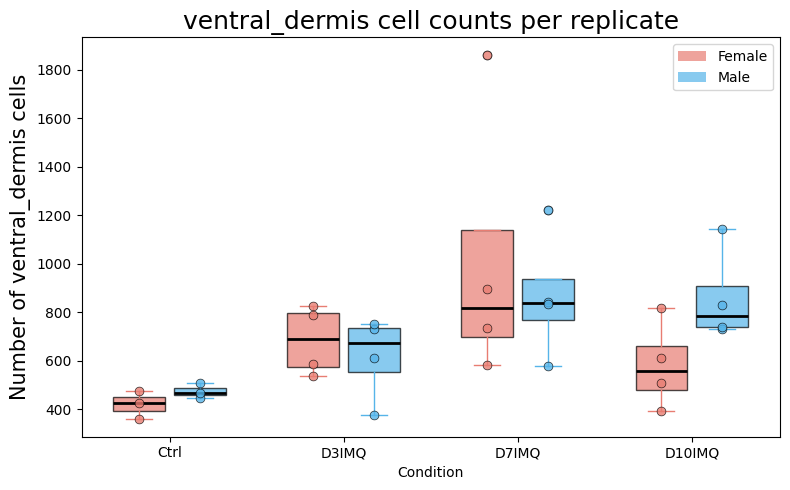

In [40]:
#plot number of cartilage cells per replicate, see if it is an appropriate normalisation measure
import matplotlib.pyplot as plt

cdata.obs['batch_key'] = cdata.obs['batch_key'].astype(str)

all_batches = cdata.obs[['batch_key']].drop_duplicates().copy()
all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
all_batches['sex'] = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

counts = cdata.obs['batch_key'].value_counts().rename('count').reset_index()
counts.columns = ['batch_key', 'count']

props = all_batches.merge(counts, on='batch_key', how='left')
props['count'] = props['count'].fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))

sex_colors = {'F': '#E87D72', 'M': '#56B4E9'}
sex_labels = {'F': 'Female', 'M': 'Male'}
width = 0.35
x = range(len(condition_order))

for sex, offset in {'F': -width/2, 'M': width/2}.items():
    sex_data = props[props['sex'] == sex]
    box_data = [
        sex_data.loc[sex_data['condition'] == cond, 'count'].values
        for cond in condition_order
    ]
    positions = [xi + offset for xi in x]
    ax.boxplot(
        box_data,
        positions=positions,
        widths=width * 0.85,
        patch_artist=True,
        manage_ticks=False,
        boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color=sex_colors[sex]),
        capprops=dict(color=sex_colors[sex]),
        flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5)
    )
    for pos, vals in zip(positions, box_data):
        ax.scatter(
            [pos] * len(vals), vals,
            color=sex_colors[sex], edgecolors='black',
            linewidths=0.5, zorder=5, s=40, alpha=0.8
        )

ax.set_xticks(list(x))
ax.set_xticklabels(condition_order)
ax.set_title(f'{normalisation_compartment} cell counts per replicate', fontsize=18)
ax.set_xlabel('Condition')
ax.set_ylabel(f'Number of {normalisation_compartment} cells', fontsize=15)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s]) for s in ['F', 'M']]
ax.legend(handles=handles)

plt.tight_layout()
plt.show()

# actually getting down to business

perichondral_fibroblast


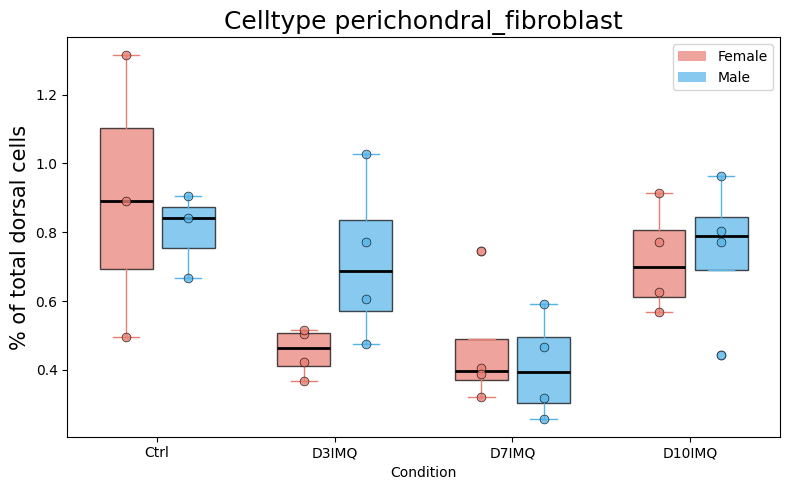

dermal_fibroblast


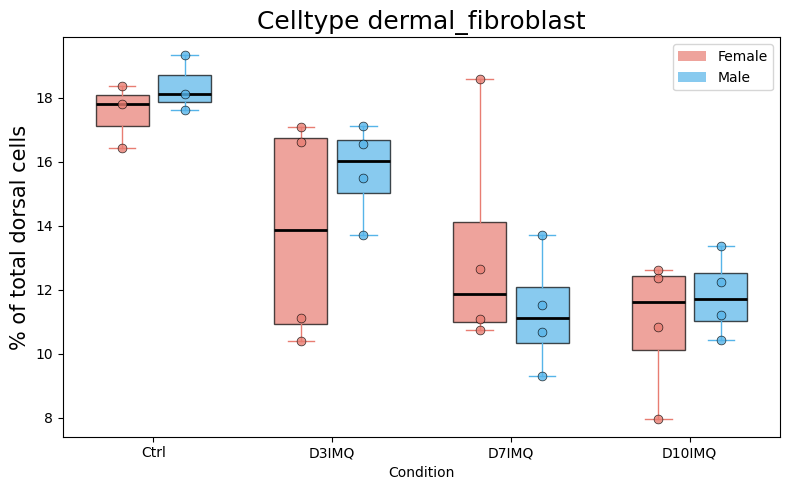

smc


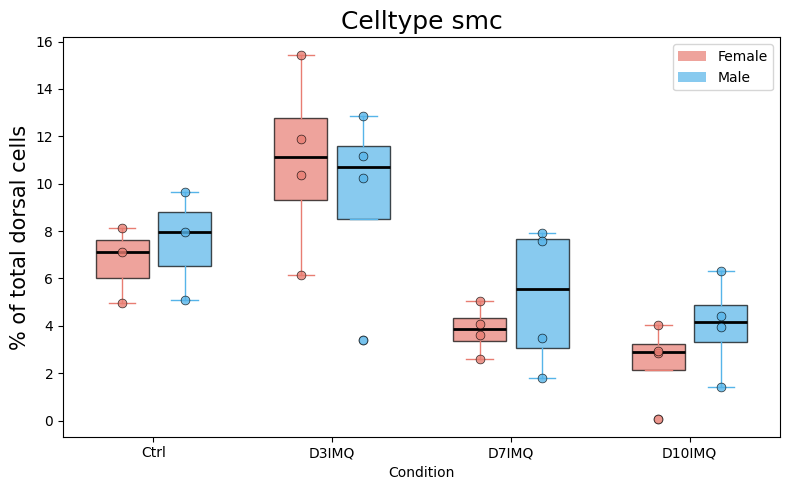

myeloid


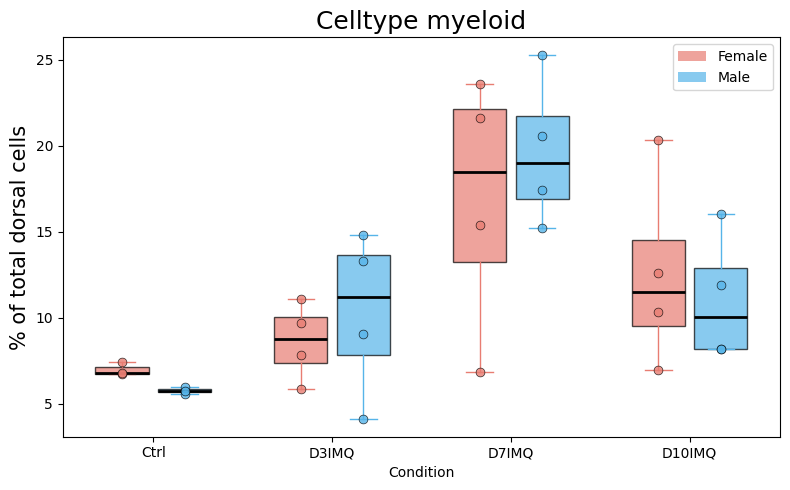

endothelial


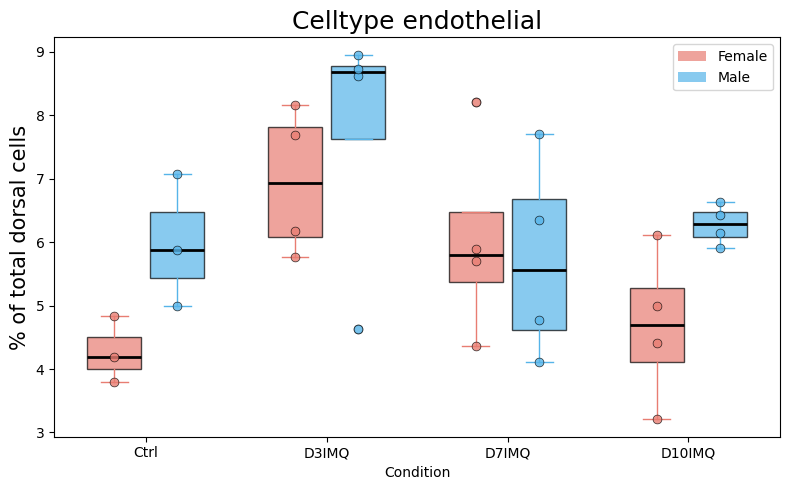

follicle_cell


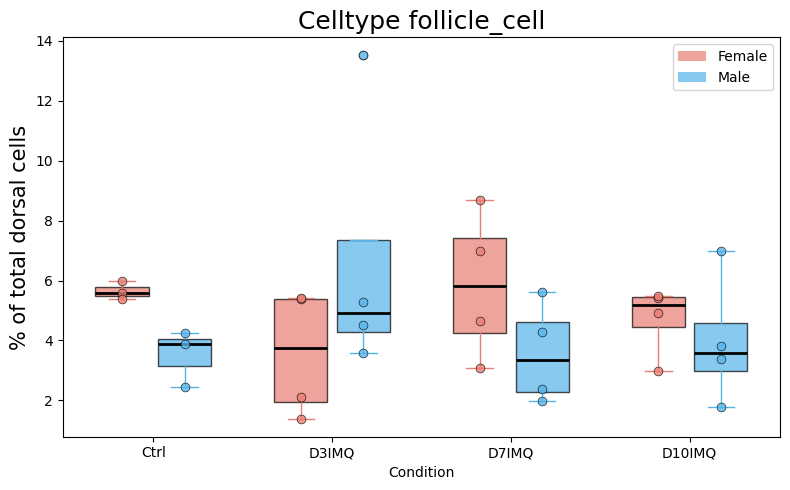

schwann_cell


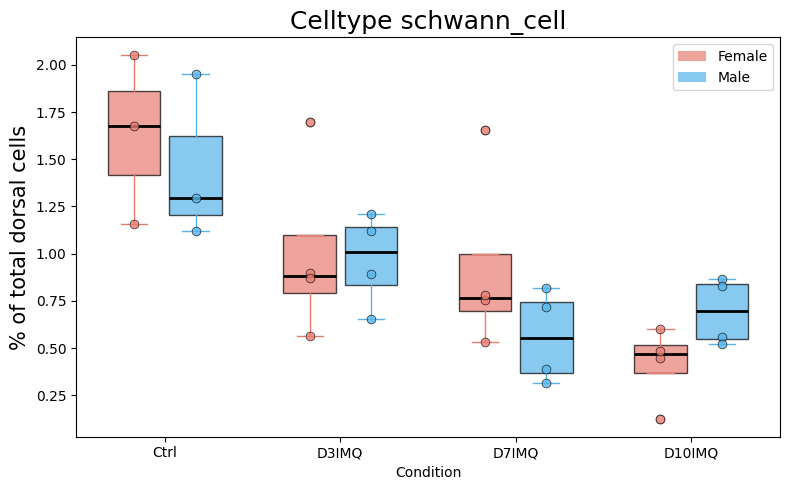

M2-like_macrophage


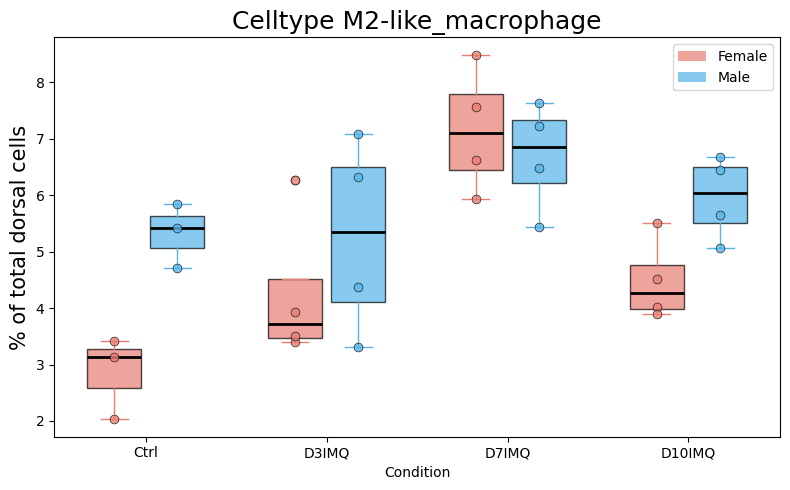

activated_basal_KC


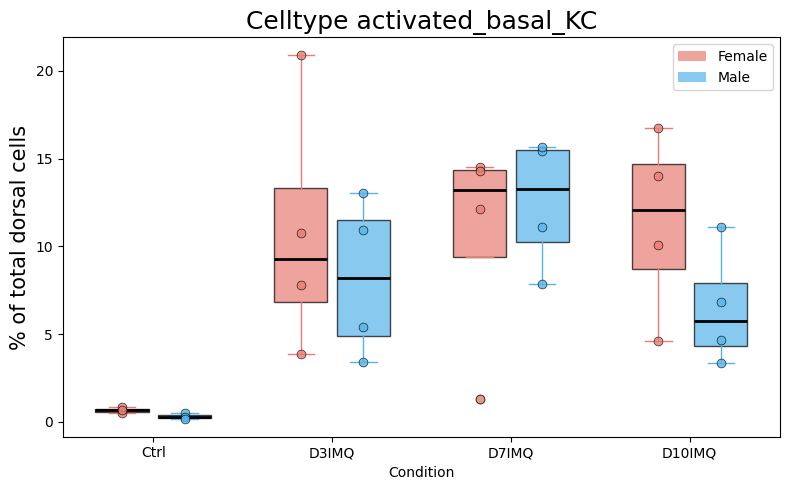

mast_cell


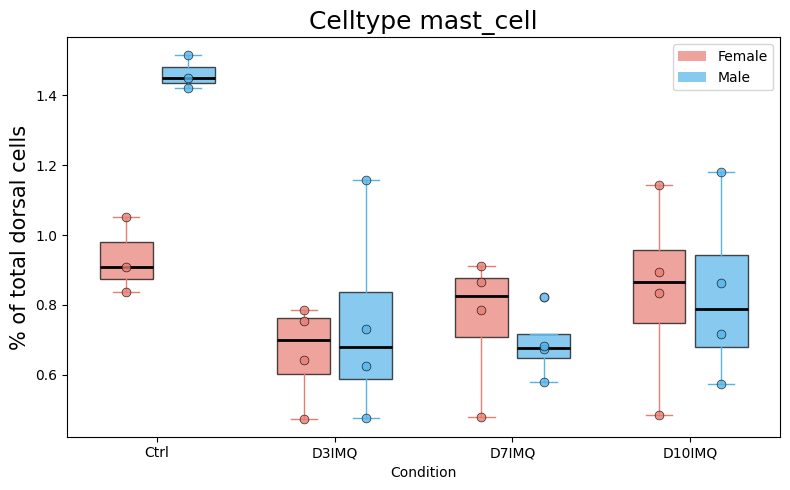

sebaceous_epithelial


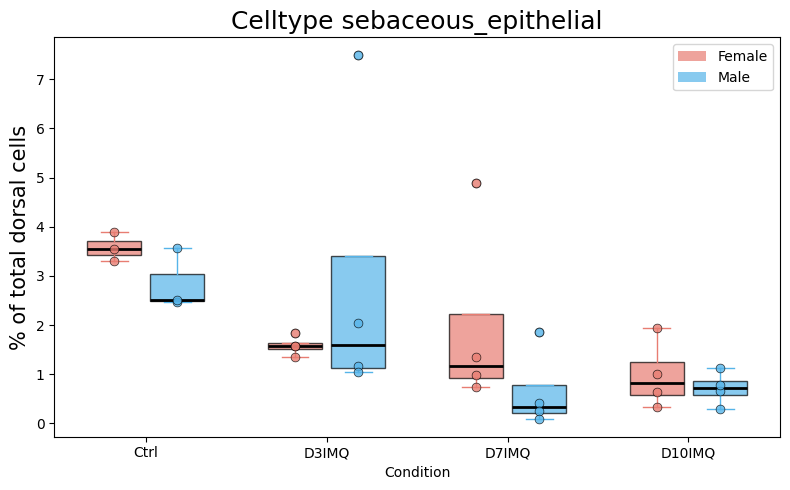

adipocyte


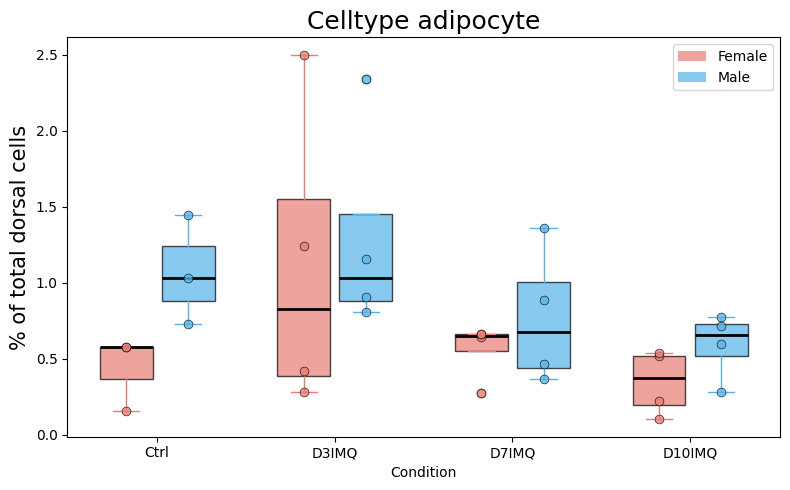

intermediate_basal_suprabasal_KC


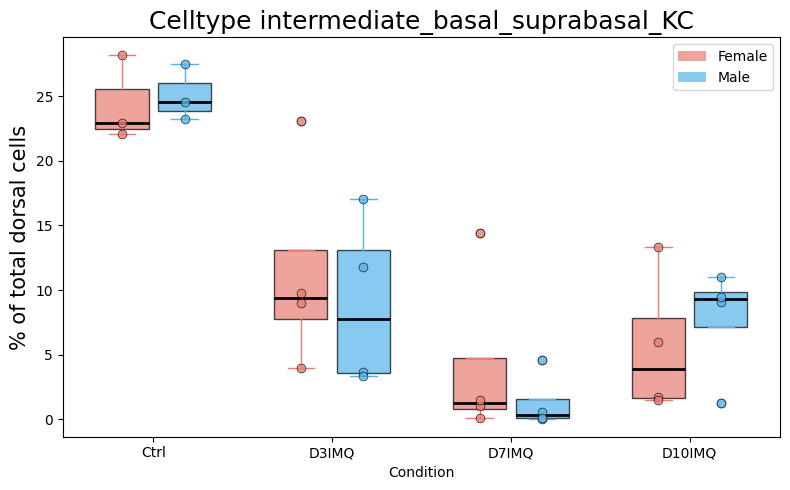

basal_KC


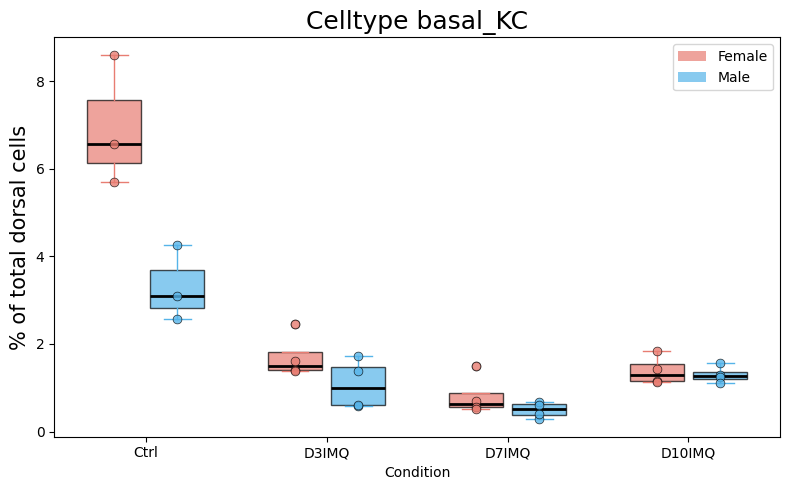

suprabasal_KC


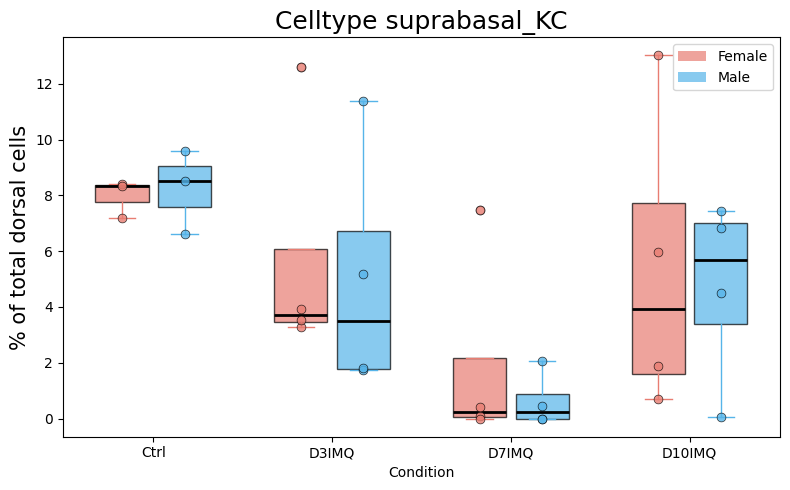

activated_suprabasal_KC


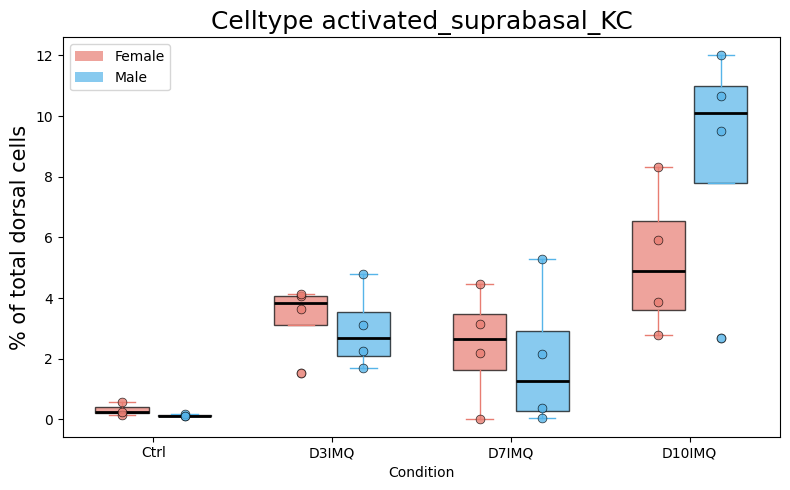

corneocyte


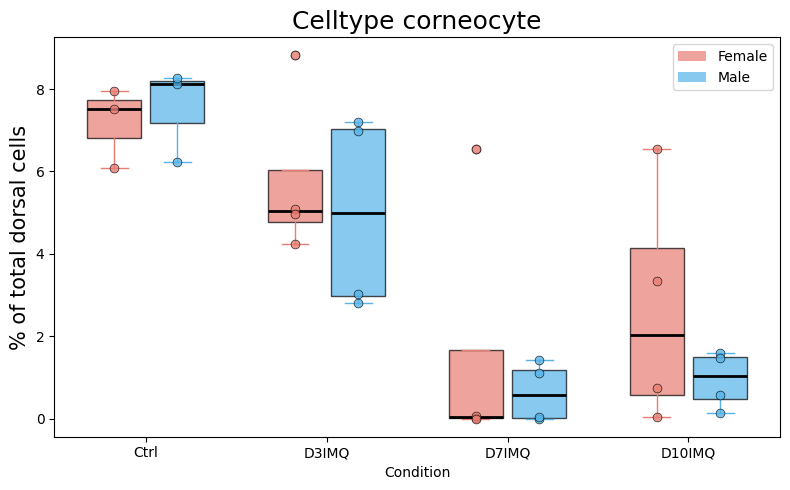

activated_corneocyte


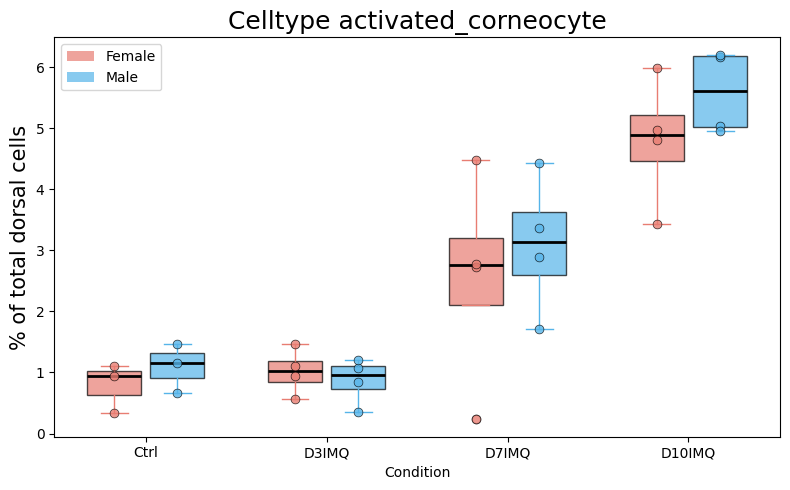

late_activated_suprabasal_KC


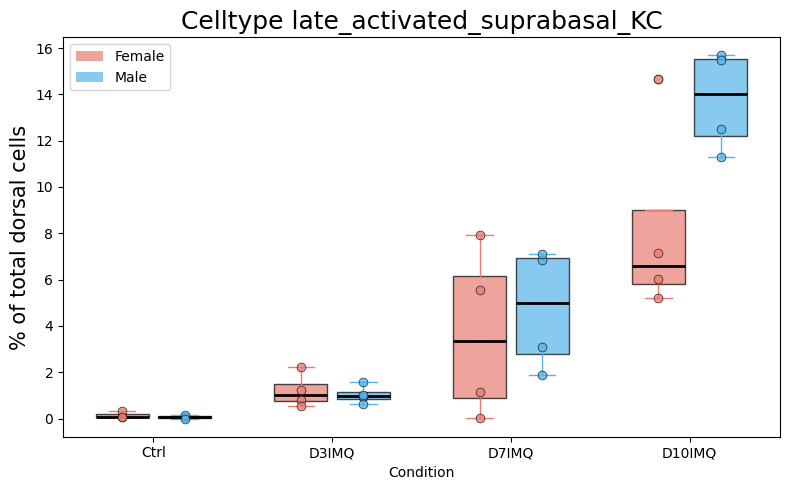

neutrophil


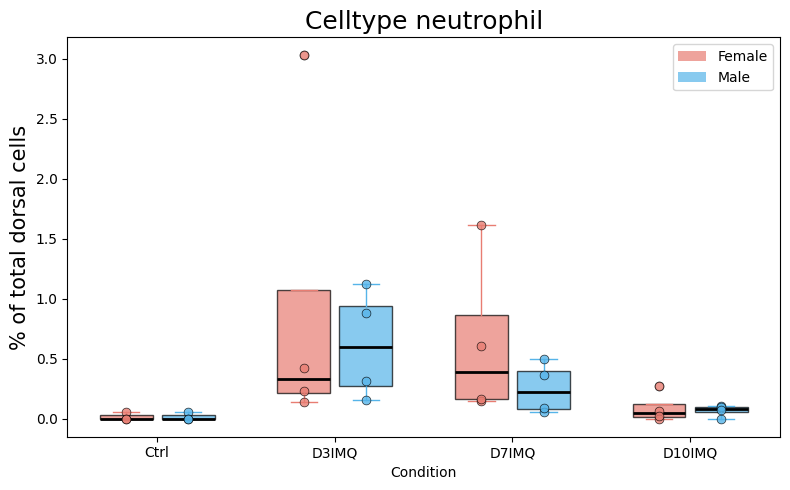

chondrocyte


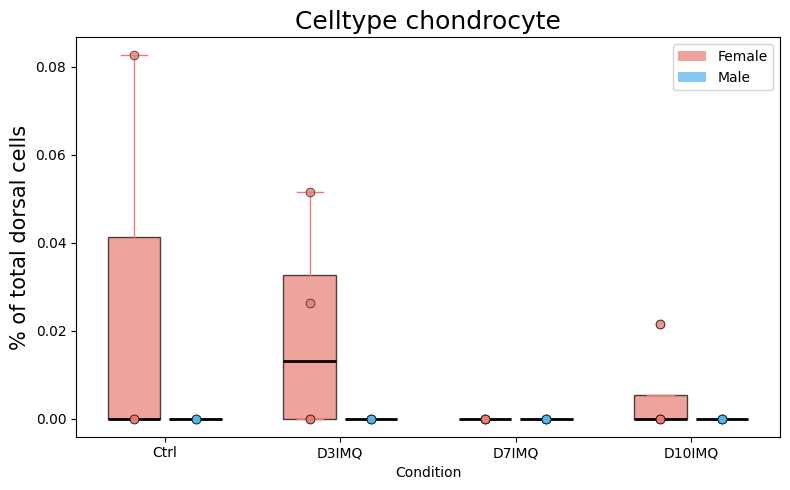

activated_intermediate_basal_suprabasal_KC


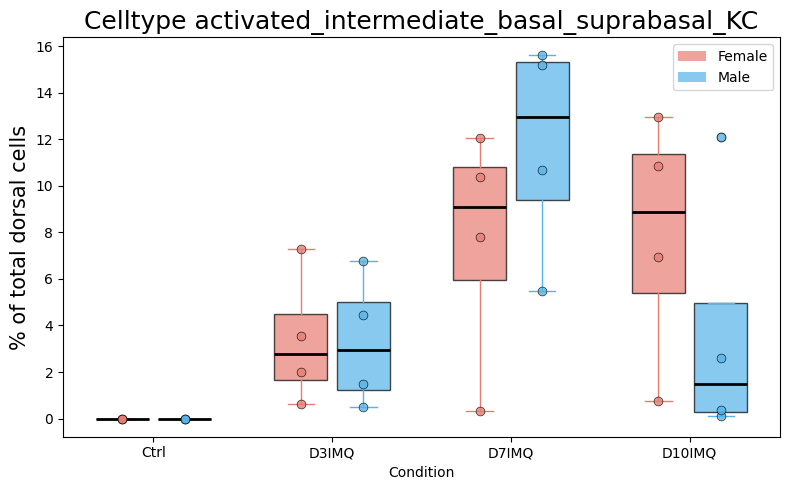

activated_spinous


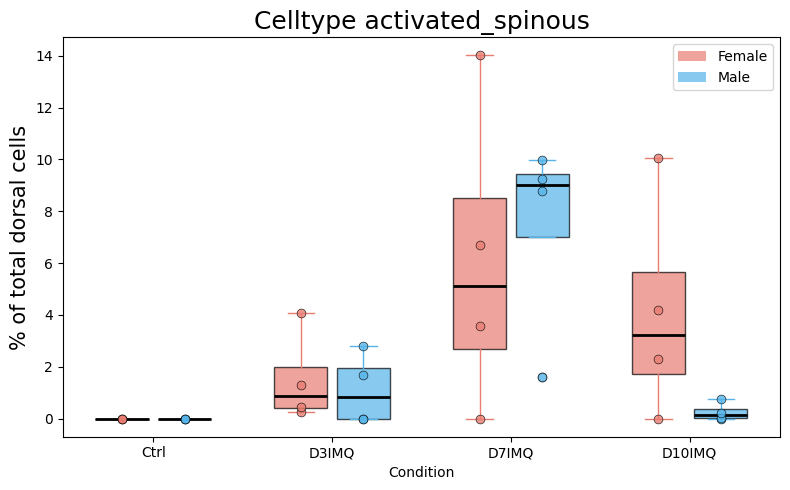

In [ ]:
#NORMALISING TO TOTAL CELLS IN REPLICATE

import matplotlib.pyplot as plt
import pandas as pd

condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

# Convert to string to avoid categorical dtype issues
bdata.obs['batch_key'] = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)

batch_totals = bdata.obs['batch_key'].value_counts()

for cluster in bdata.obs['celltype_assignments'].unique():
    print(cluster)
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster].copy()

    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    props['condition'] = props['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    props['sex'] = props['batch_key'].str.extract(r'_([FM])\d+$')

    all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex'] = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # Convert all relevant columns to string before merge/fillna
    for df in [props, all_batches]:
        for col in ['batch_key', 'condition', 'sex']:
            df[col] = df[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)  # Only fillna on the numeric column

    fig, ax = plt.subplots(figsize=(8, 5))

    sex_colors = {'F': '#E87D72', 'M': '#56B4E9'}
    sex_labels = {'F': 'Female', 'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    for i, (sex, offset) in enumerate({'F': -width/2, 'M': width/2}.items()):
        sex_data = props[props['sex'] == sex]

        box_data = [
            sex_data.loc[sex_data['condition'] == cond, 'proportion'].values
            for cond in condition_order
        ]

        positions = [xi + offset for xi in x]
        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5)
        )

        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Celltype {cluster}', fontsize=18)
    ax.set_xlabel('Condition')
    ax.set_ylabel('% of total dorsal cells', fontsize=15)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s]) for s in ['F', 'M']]
    ax.legend(handles=handles)

    plt.tight_layout()
    plt.show()

perichondral_fibroblast


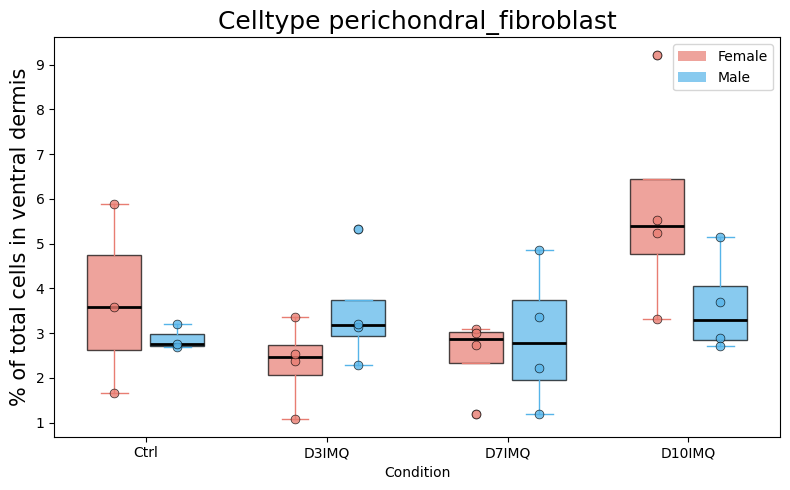

dermal_fibroblast


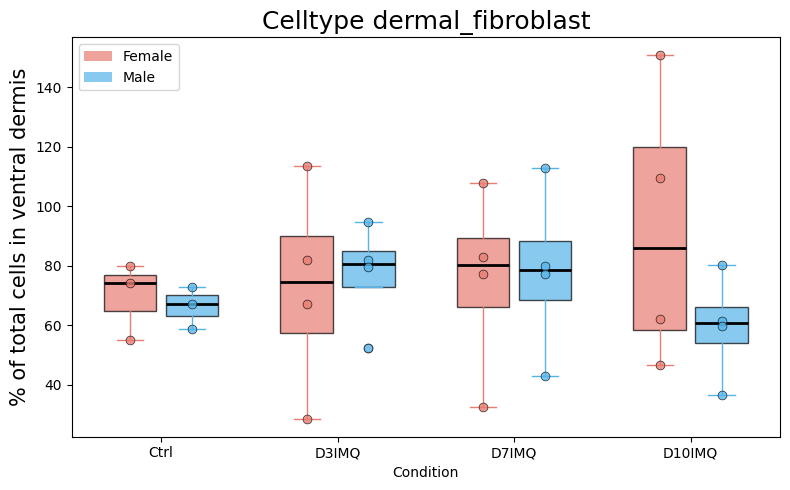

smc


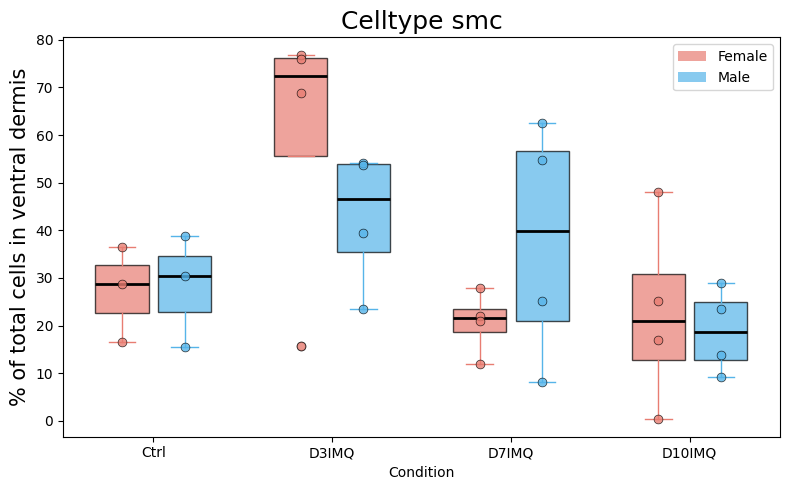

myeloid


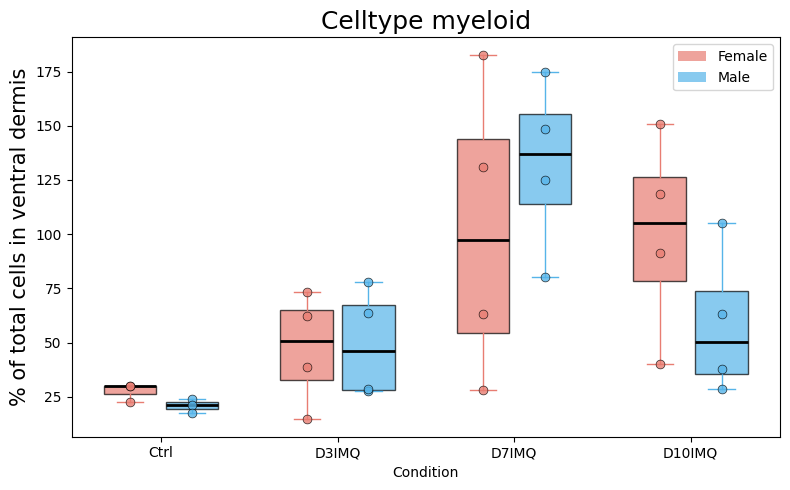

endothelial


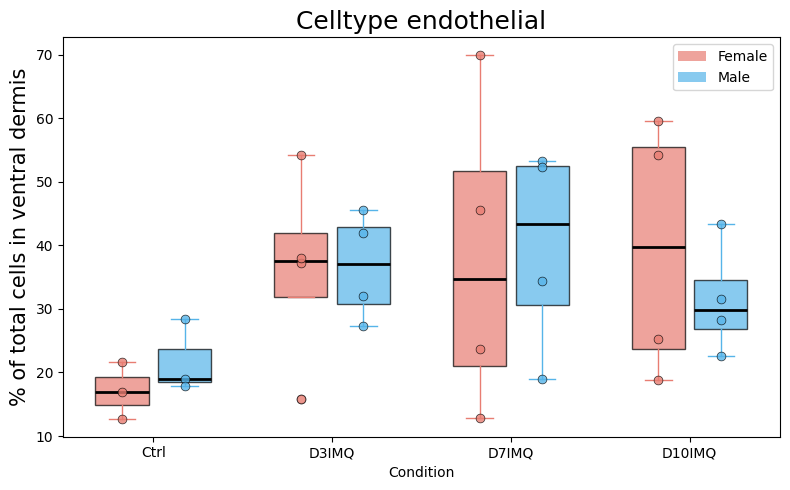

follicle_cell


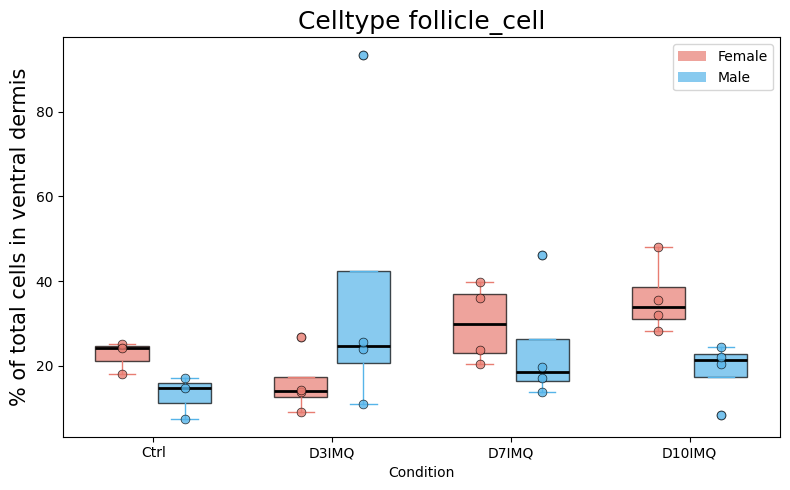

schwann_cell


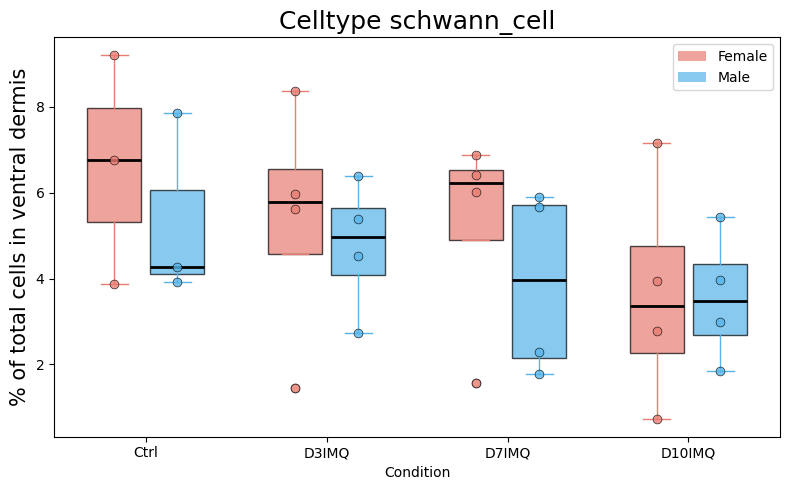

M2-like_macrophage


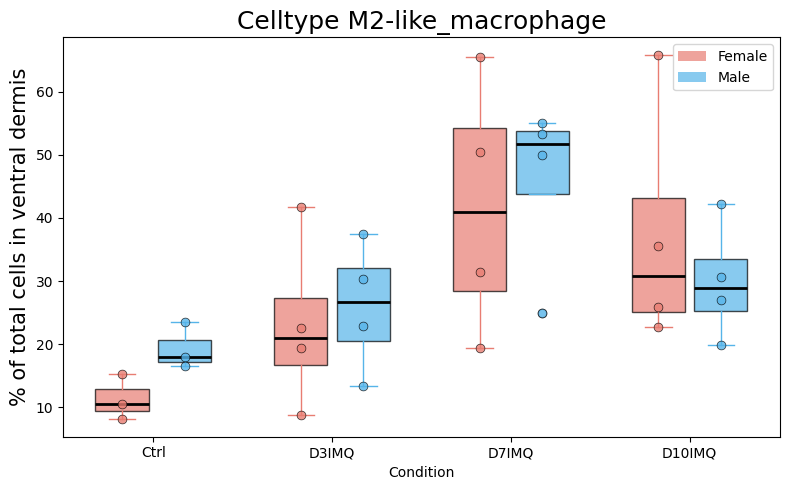

activated_basal_KC


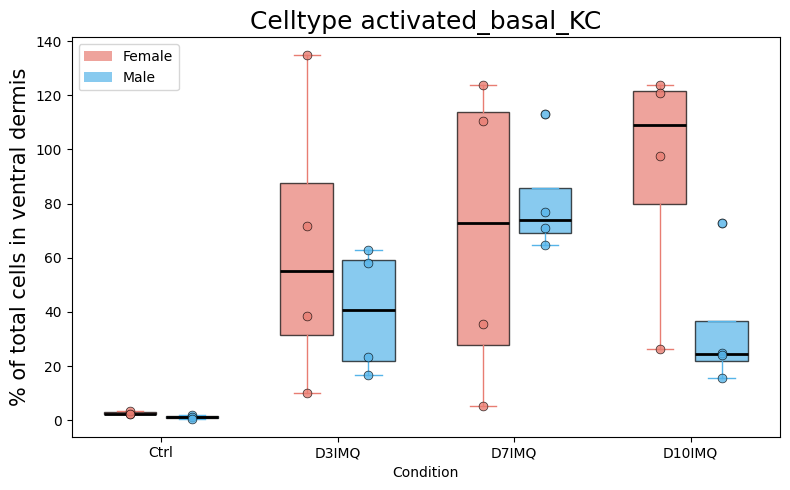

mast_cell


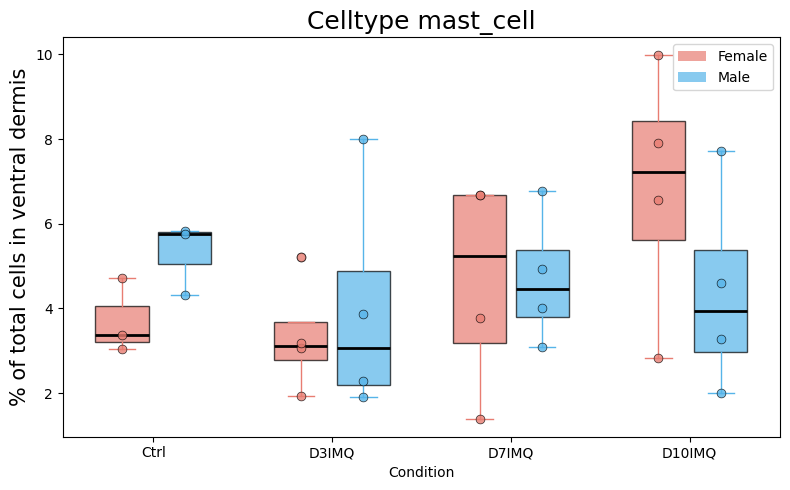

sebaceous_epithelial


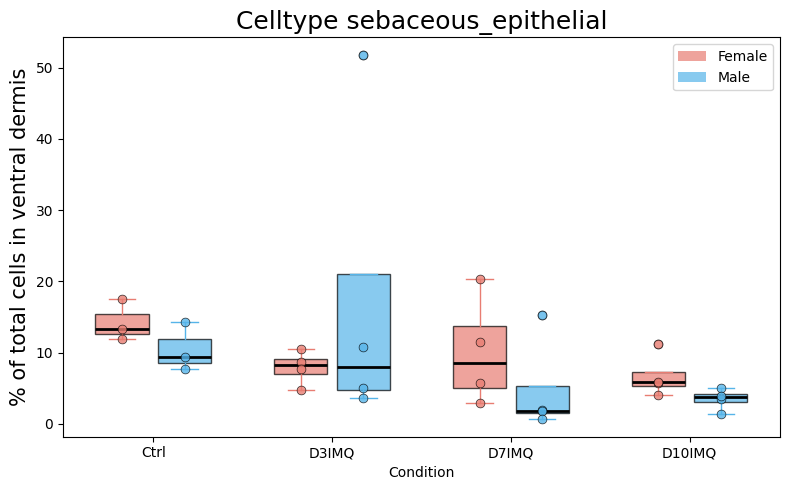

adipocyte


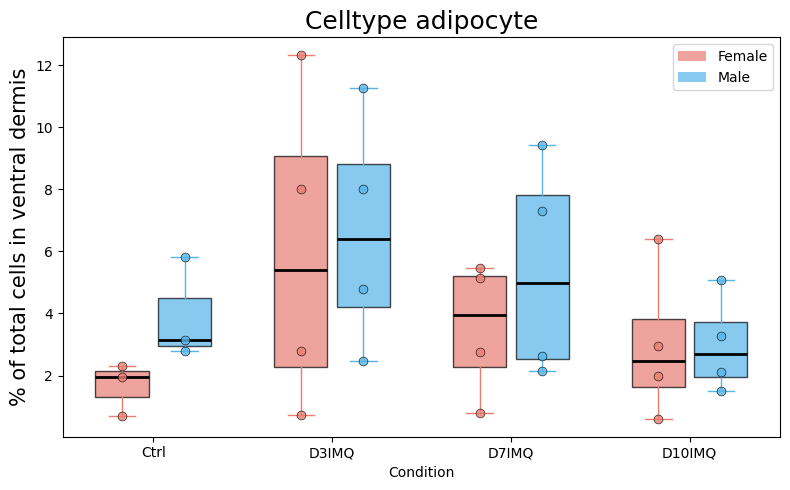

intermediate_basal_suprabasal_KC


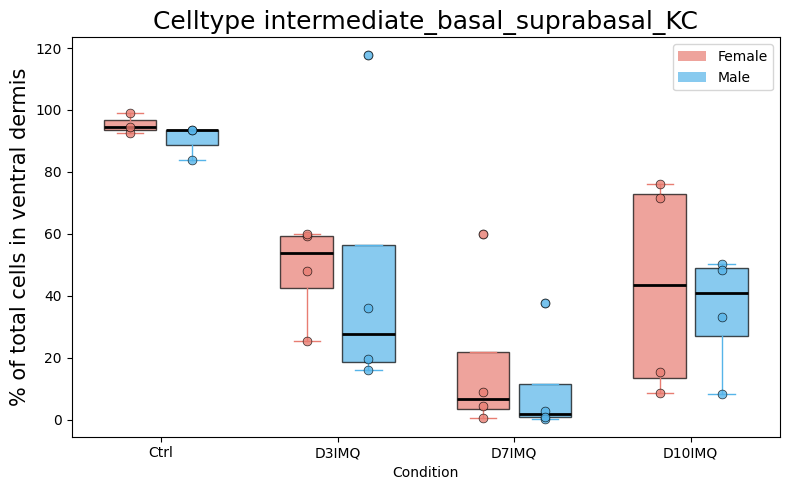

basal_KC


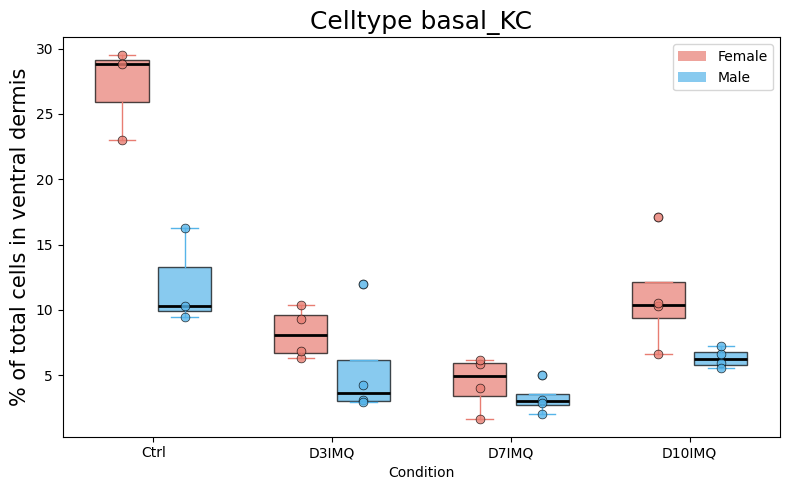

suprabasal_KC


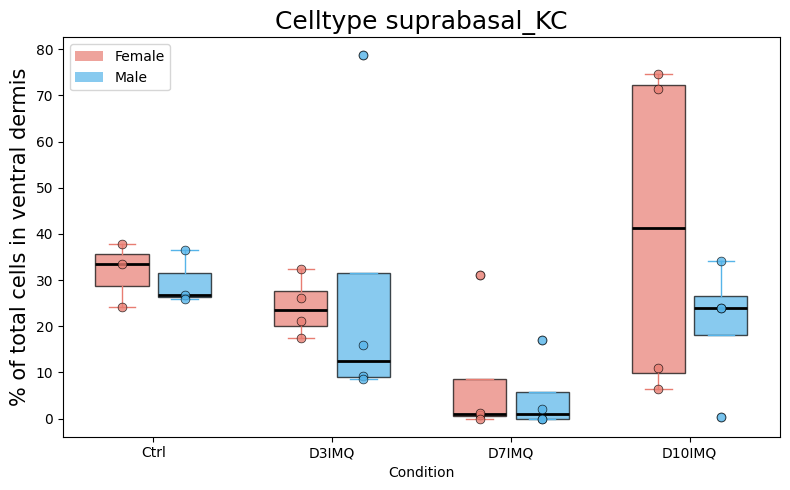

activated_suprabasal_KC


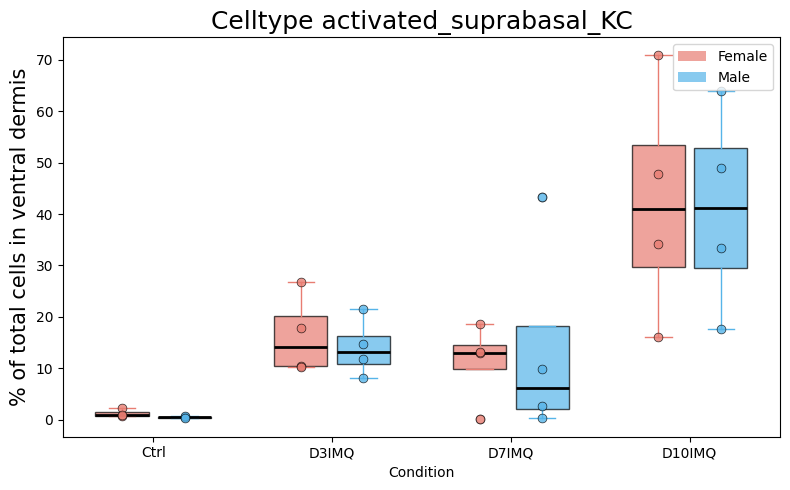

corneocyte


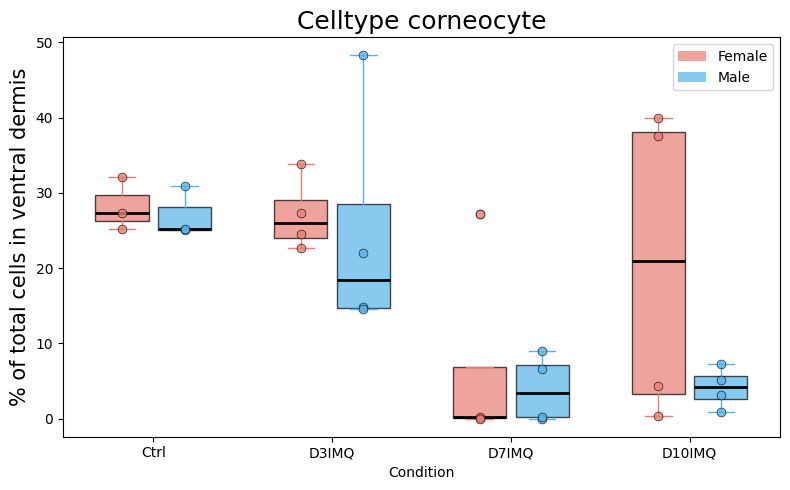

activated_corneocyte


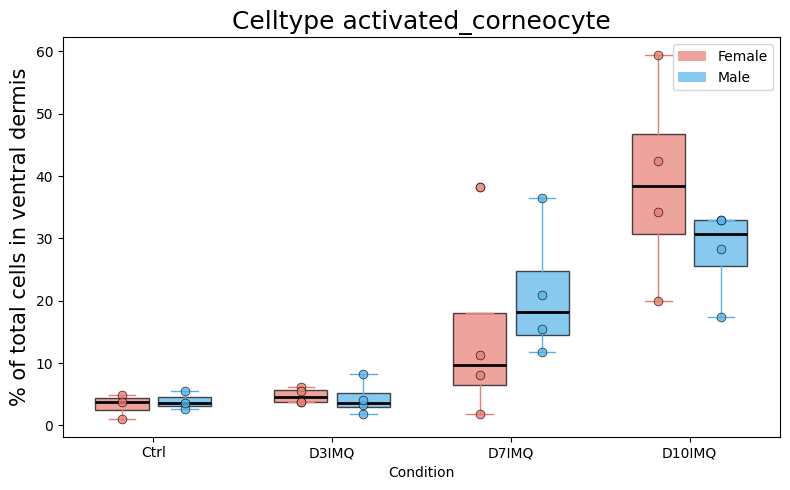

late_activated_suprabasal_KC


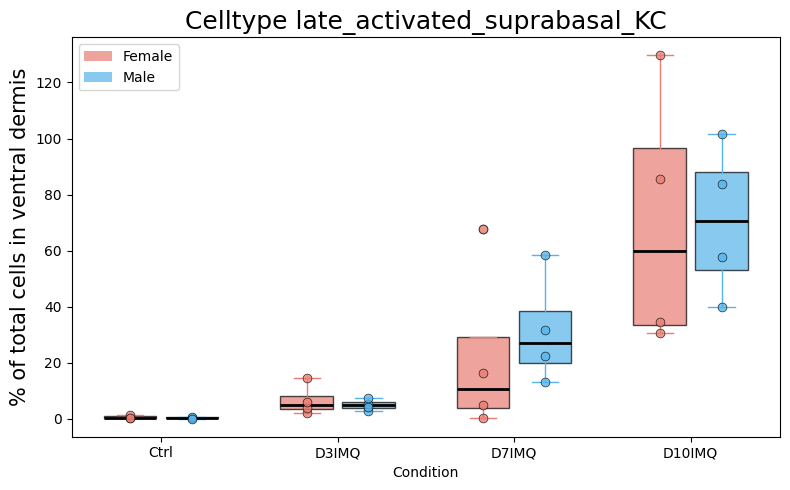

neutrophil


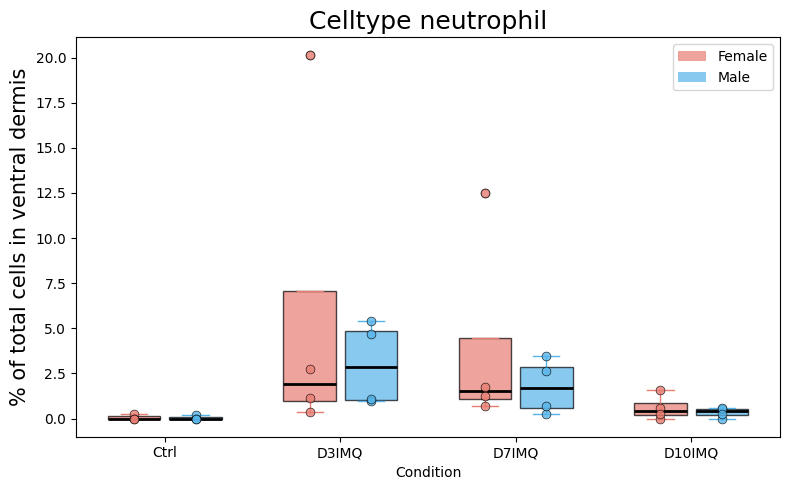

chondrocyte


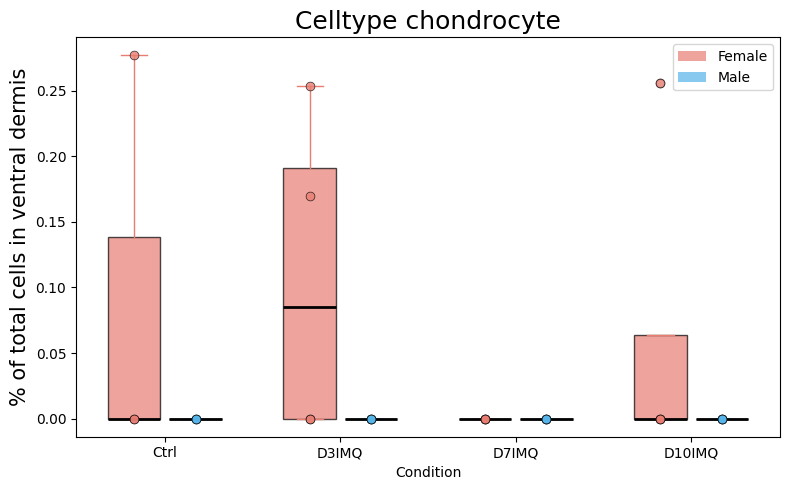

activated_intermediate_basal_suprabasal_KC


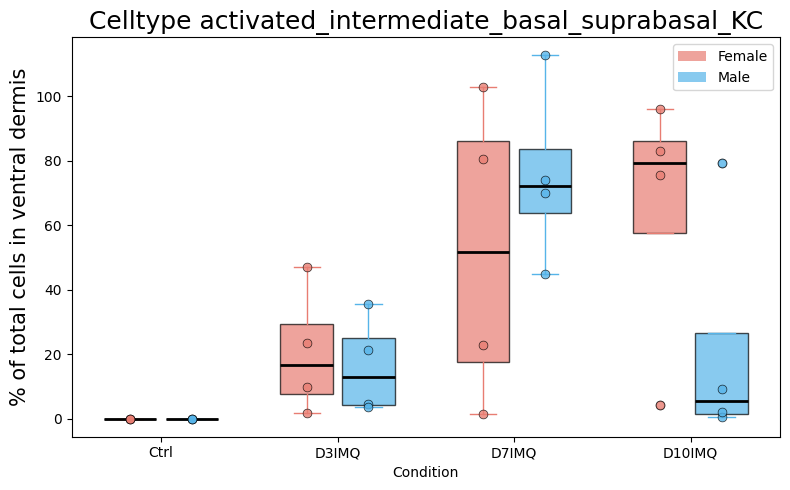

activated_spinous


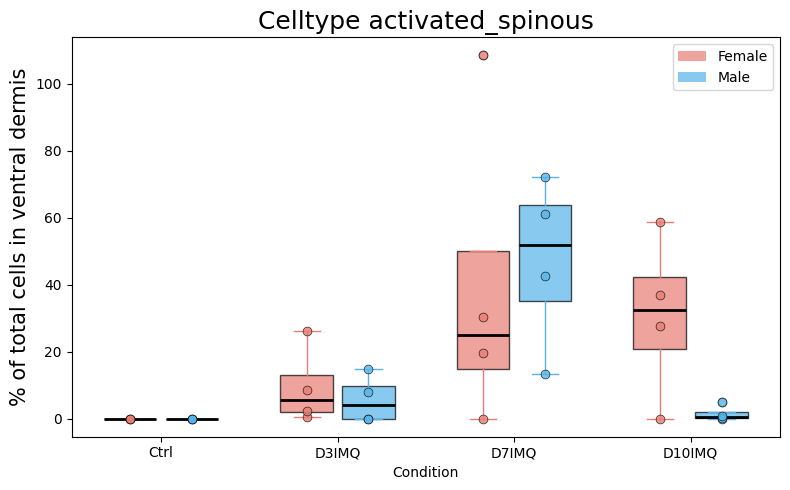

In [ ]:
#CELLS NORMALISED TO WHATEVER COMPARTMENT IS IN 'normalisation_compartment'

import matplotlib.pyplot as plt
import pandas as pd



condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

# Convert to string to avoid categorical dtype issues
bdata.obs['batch_key'] = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)

batch_totals = cdata.obs['batch_key'].astype(str).value_counts() #KEY NORMALISATION STEP THAT DIFFERS FROM ABOVE FUNCTION

for cluster in bdata.obs['celltype_assignments'].unique():
    print(cluster)
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster].copy()

    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    props['condition'] = props['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    props['sex'] = props['batch_key'].str.extract(r'_([FM])\d+$')

    all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex'] = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # Convert all relevant columns to string before merge/fillna
    for df in [props, all_batches]:
        for col in ['batch_key', 'condition', 'sex']:
            df[col] = df[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)  # Only fillna on the numeric column

    fig, ax = plt.subplots(figsize=(8, 5))

    sex_colors = {'F': '#E87D72', 'M': '#56B4E9'}
    sex_labels = {'F': 'Female', 'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    for i, (sex, offset) in enumerate({'F': -width/2, 'M': width/2}.items()):
        sex_data = props[props['sex'] == sex]

        box_data = [
            sex_data.loc[sex_data['condition'] == cond, 'proportion'].values
            for cond in condition_order
        ]

        positions = [xi + offset for xi in x]
        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=sex_colors[sex], alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=sex_colors[sex]),
            capprops=dict(color=sex_colors[sex]),
            flierprops=dict(marker='o', color=sex_colors[sex], alpha=0.5)
        )

        for pos, vals in zip(positions, box_data):
            ax.scatter(
                [pos] * len(vals), vals,
                color=sex_colors[sex], edgecolors='black',
                linewidths=0.5, zorder=5, s=40, alpha=0.8
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Celltype {cluster}', fontsize=18)
    ax.set_xlabel('Condition')
    ax.set_ylabel('% of total cells in ventral dermis', fontsize=15) #MAKE SURE YOU CHANGE THIS TO WHATEVER IS IN NORMALISATION COMPARTMENT

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s]) for s in ['F', 'M']]
    ax.legend(handles=handles)

    plt.tight_layout()
    plt.show()

perichondral_fibroblast


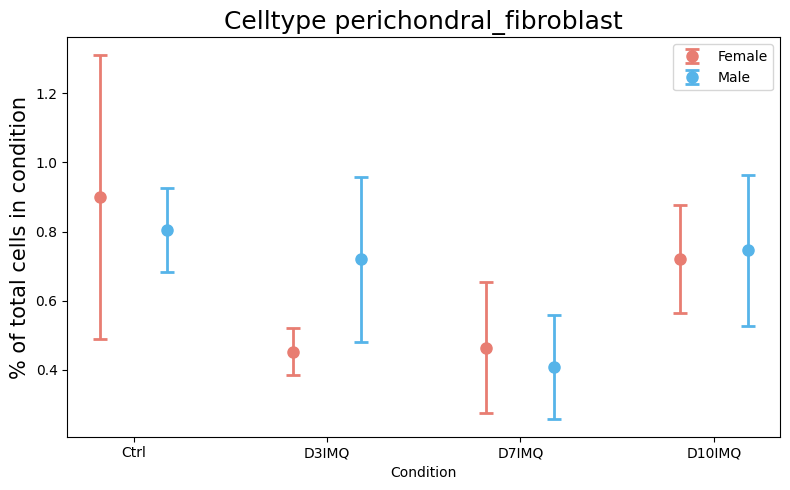

dermal_fibroblast


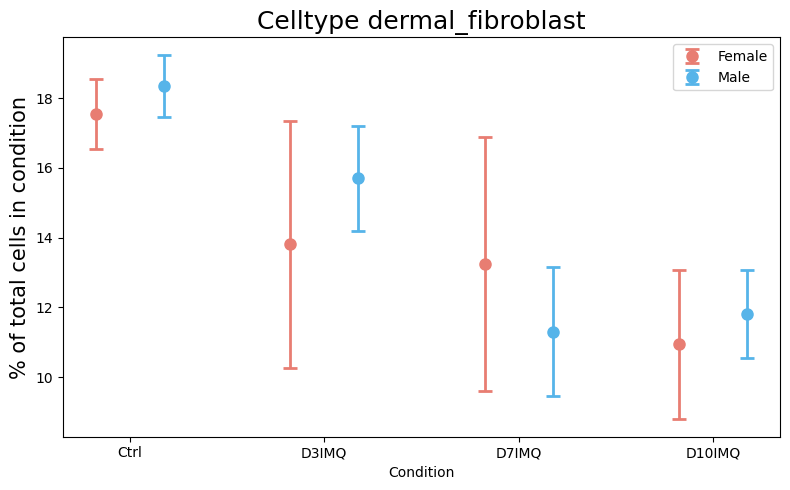

smc


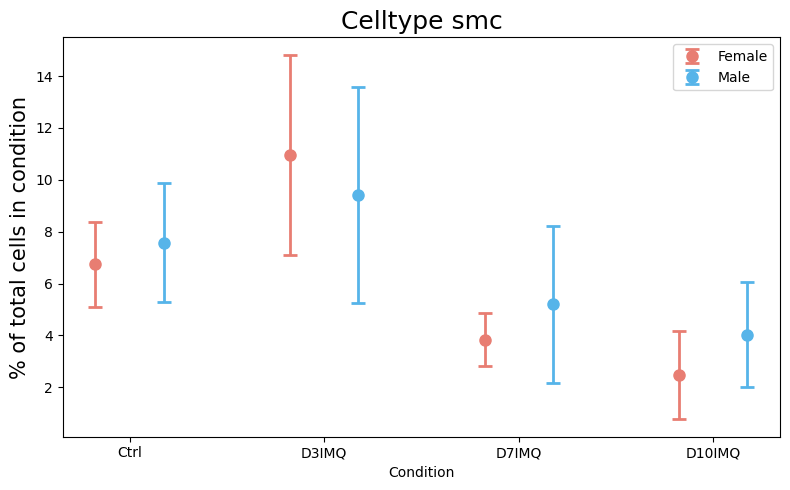

myeloid


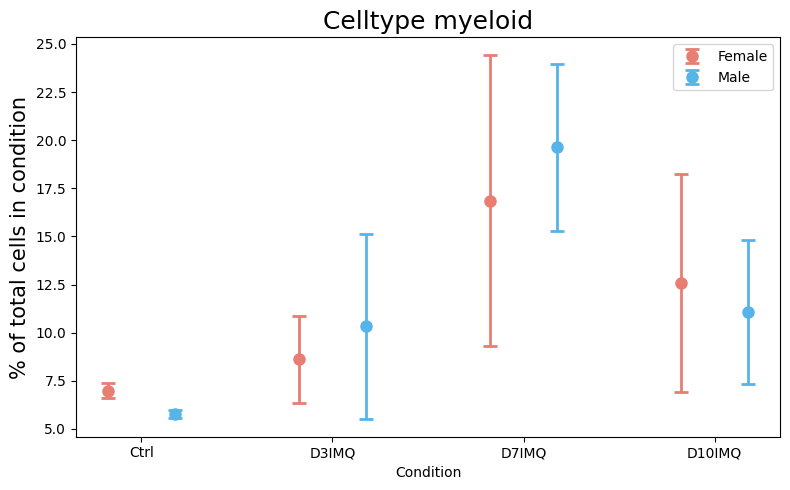

endothelial


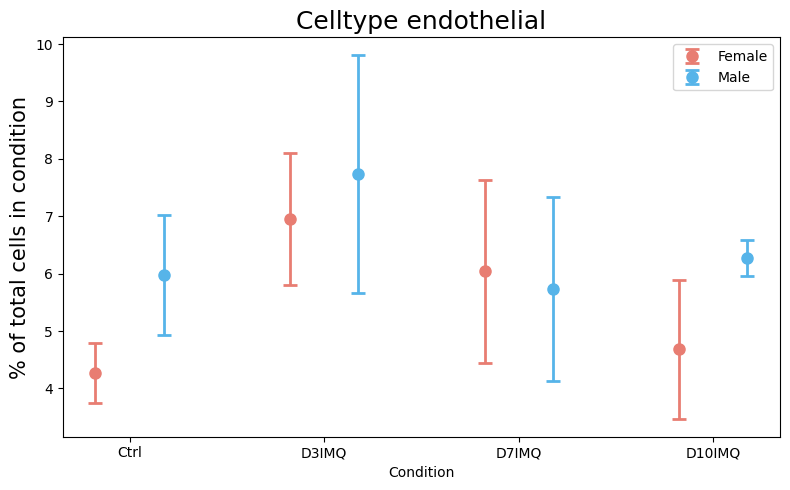

follicle_cell


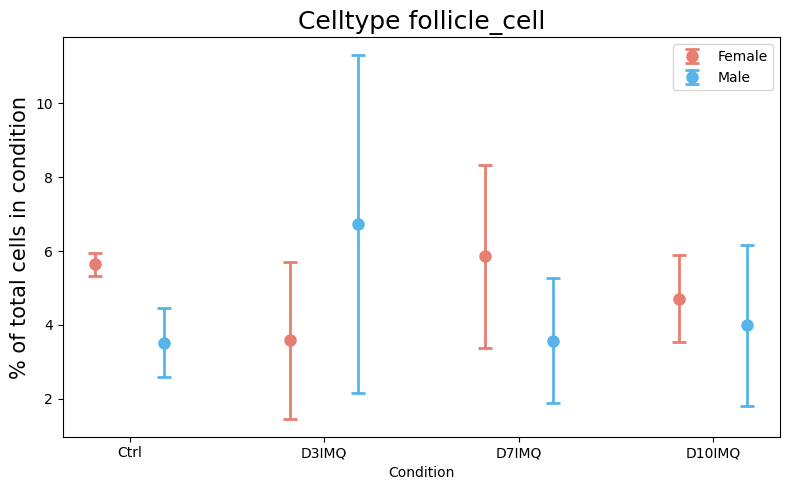

schwann_cell


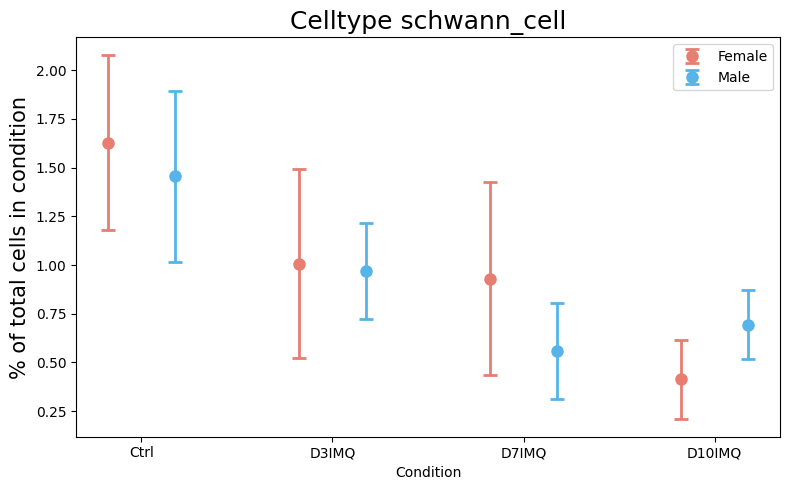

M2-like_macrophage


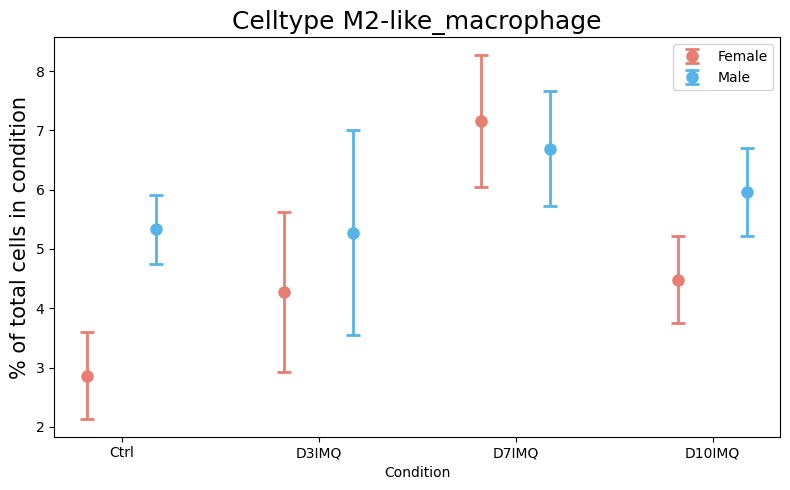

activated_basal_KC


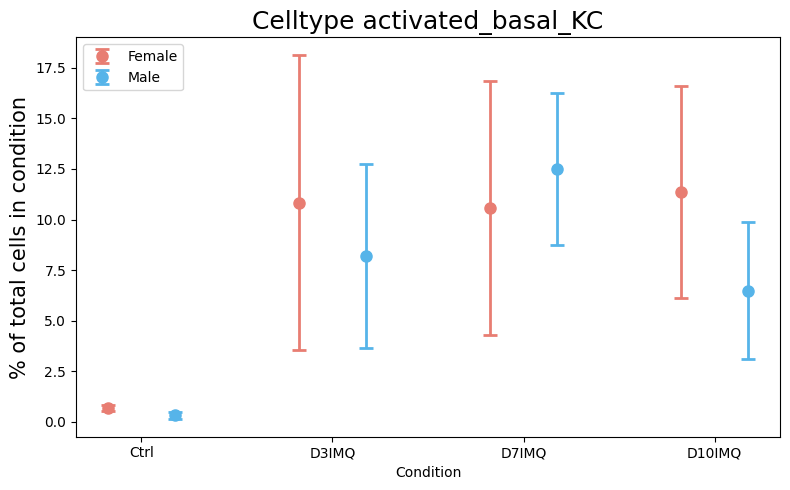

mast_cell


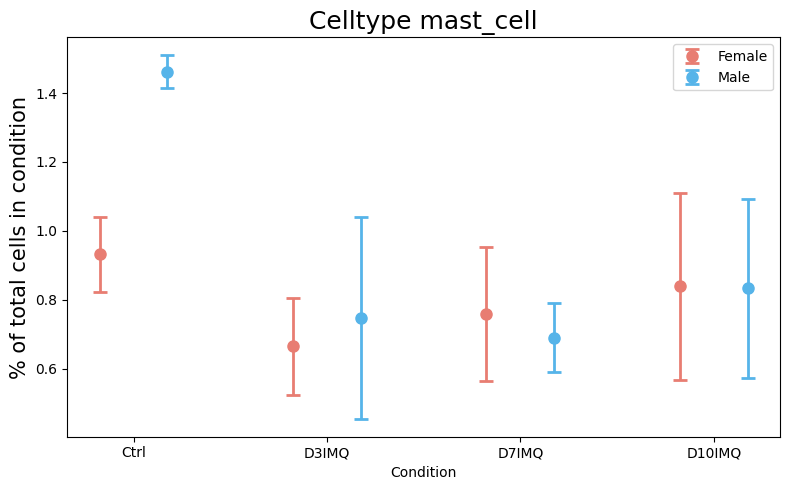

sebaceous_epithelial


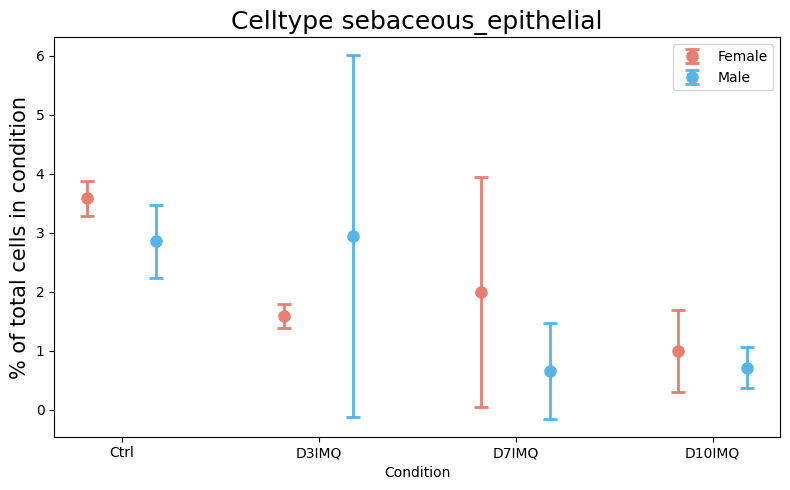

adipocyte


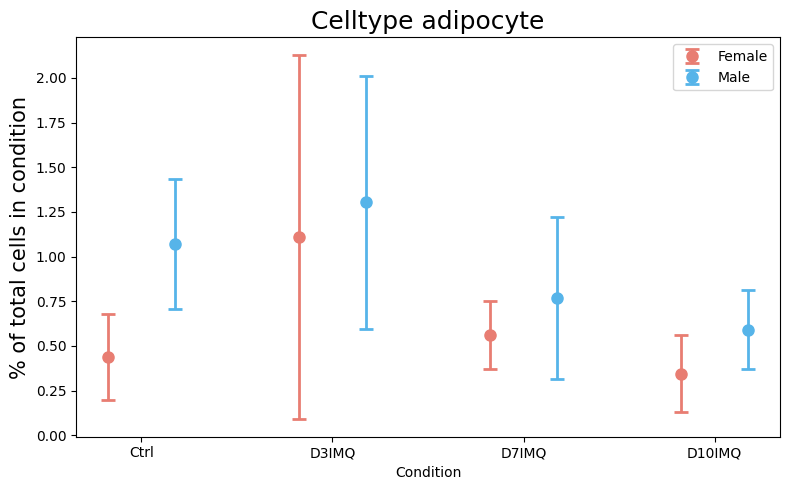

intermediate_basal_suprabasal_KC


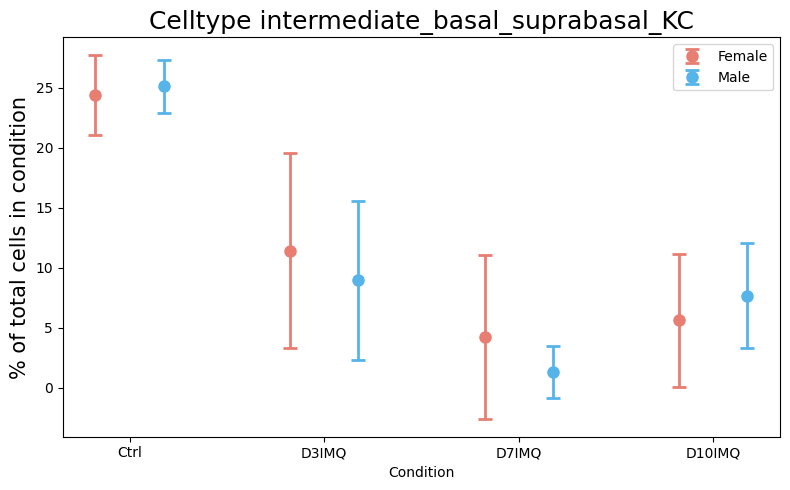

basal_KC


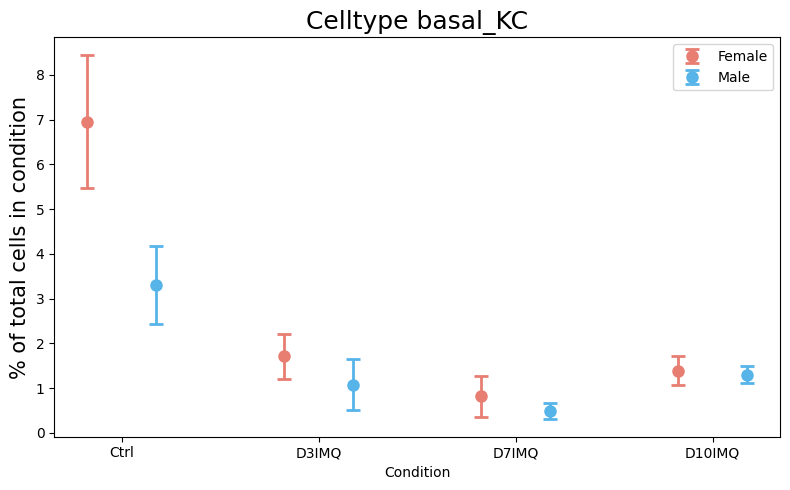

suprabasal_KC


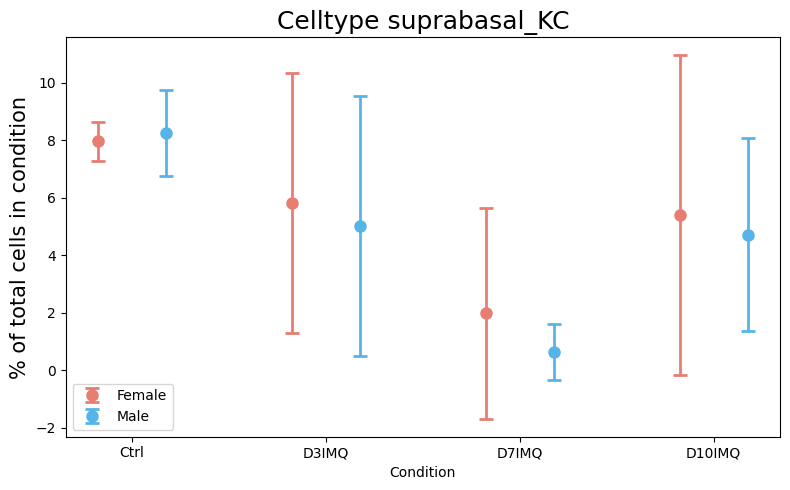

activated_suprabasal_KC


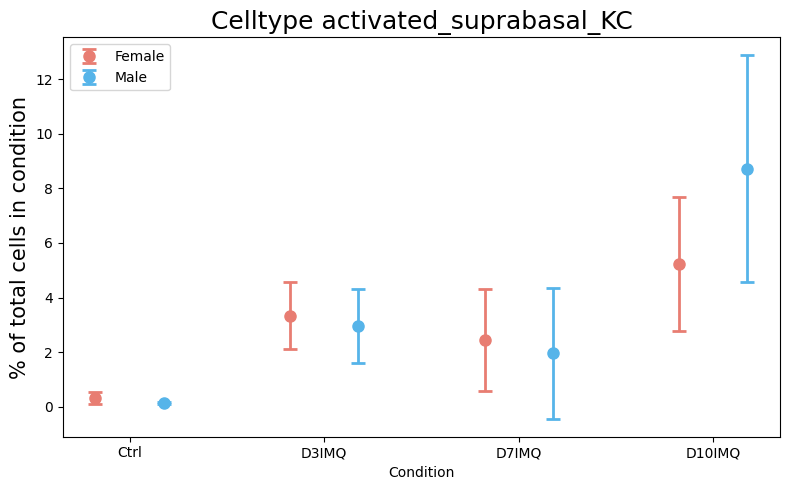

corneocyte


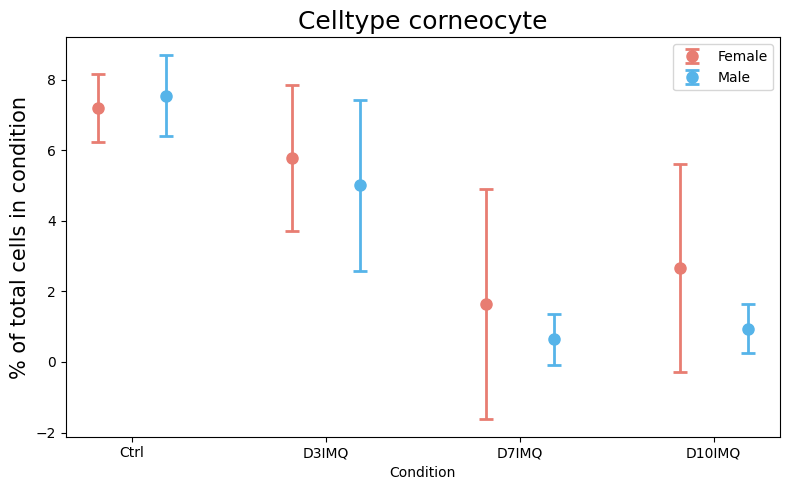

activated_corneocyte


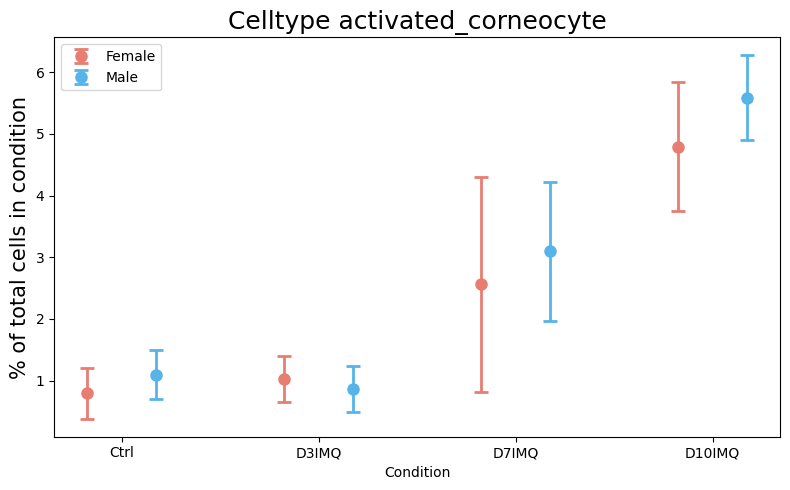

late_activated_suprabasal_KC


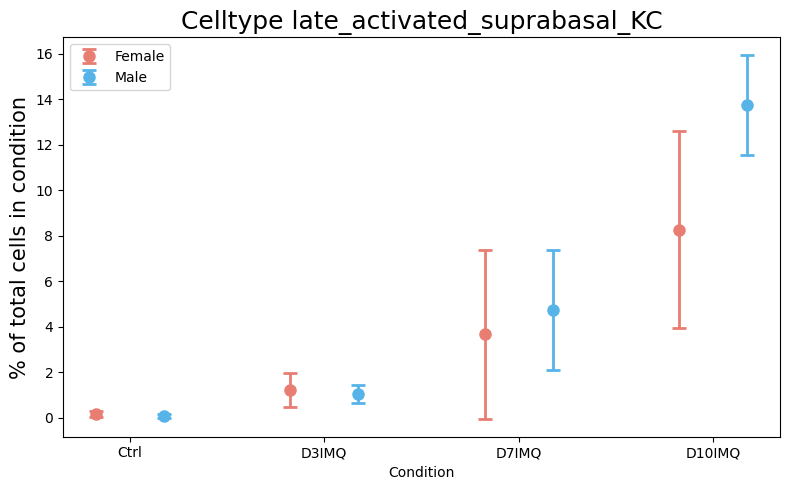

neutrophil


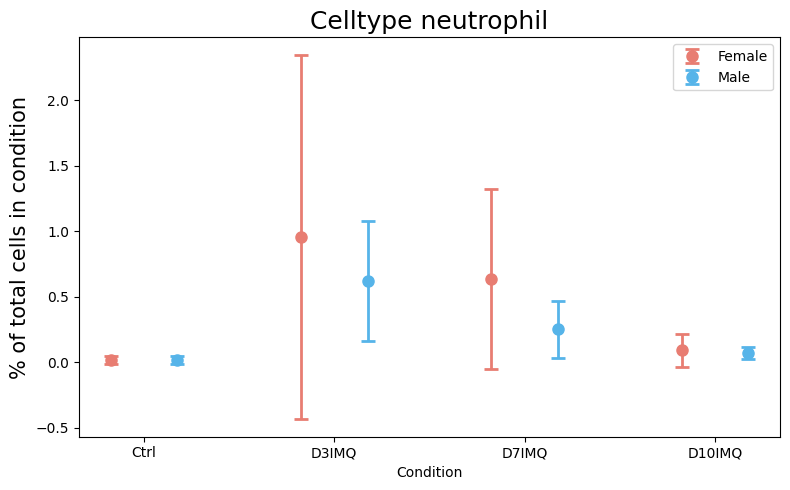

chondrocyte


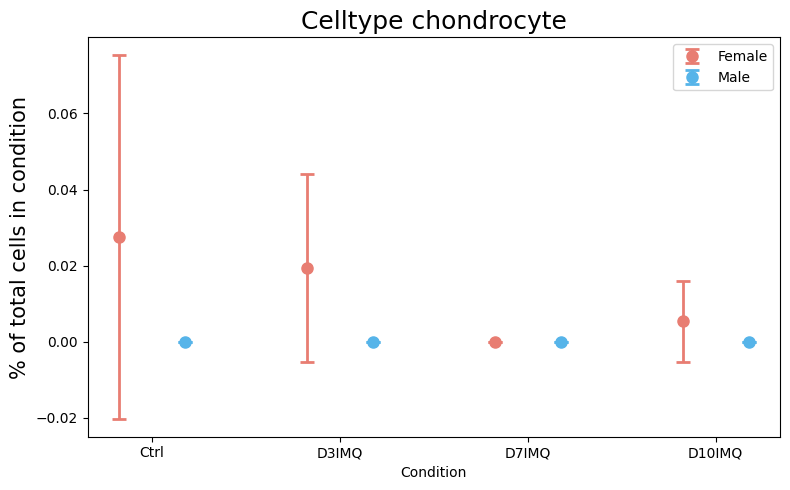

activated_intermediate_basal_suprabasal_KC


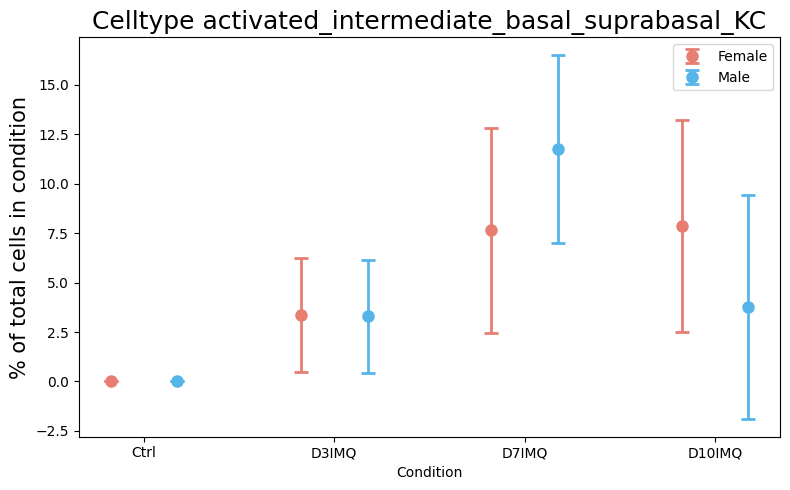

activated_spinous


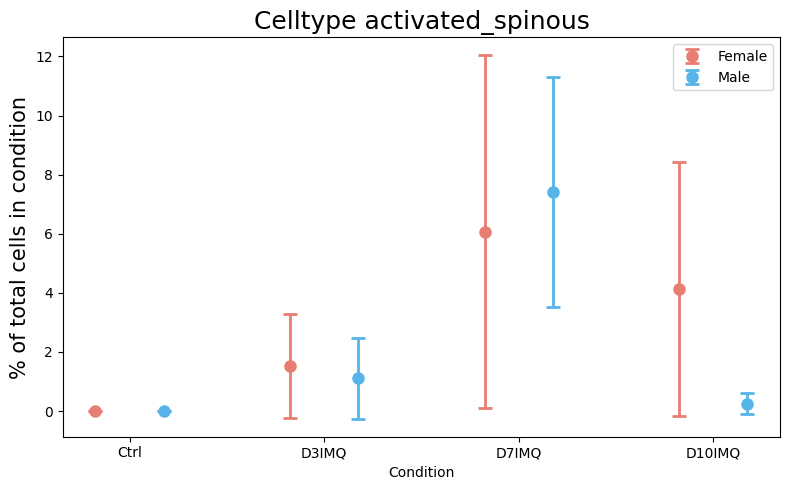

In [ ]:
#normalised to total cells across condition (dorsal side)
#mean and error bar (std) version of above plot

import matplotlib.pyplot as plt
import pandas as pd

condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

# Convert to string to avoid categorical dtype issues
bdata.obs['batch_key'] = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)

batch_totals = bdata.obs['batch_key'].value_counts()

for cluster in bdata.obs['celltype_assignments'].unique():
    print(cluster)
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster].copy()

    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    props['condition'] = props['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    props['sex'] = props['batch_key'].str.extract(r'_([FM])\d+$')

    all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex'] = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # Convert all relevant columns to string before merge/fillna
    for df in [props, all_batches]:
        for col in ['batch_key', 'condition', 'sex']:
            df[col] = df[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)  # Only fillna on the numeric column

    fig, ax = plt.subplots(figsize=(8, 5))

    sex_colors = {'F': '#E87D72', 'M': '#56B4E9'}
    sex_labels = {'F': 'Female', 'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    for sex, offset in {'F': -width/2, 'M': width/2}.items():
        sex_data = props[props['sex'] == sex]

        means = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].mean() for cond in condition_order]
        stds  = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].std()  for cond in condition_order]

        positions = [xi + offset for xi in x]

        ax.errorbar(
            positions, means, yerr=stds,
            fmt='o', color=sex_colors[sex],
            ecolor=sex_colors[sex], elinewidth=2,
            capsize=5, capthick=2,
            markersize=8, label=sex_labels[sex],
            zorder=3
        )

        # # Overlay individual points
        # for pos, cond in zip(positions, condition_order):
        #     vals = sex_data.loc[sex_data['condition'] == cond, 'proportion'].values
        #     ax.scatter(
        #         [pos] * len(vals), vals,
        #         color=sex_colors[sex], edgecolors='black',
        #         linewidths=0.5, zorder=5, s=30, alpha=0.6
        #     )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Celltype {cluster}', fontsize=18)
    ax.set_xlabel('Condition')
    ax.set_ylabel('% of total cells in condition', fontsize=15)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s]) for s in ['F', 'M']]
    ax.legend()

    plt.tight_layout()
    plt.show()

perichondral_fibroblast


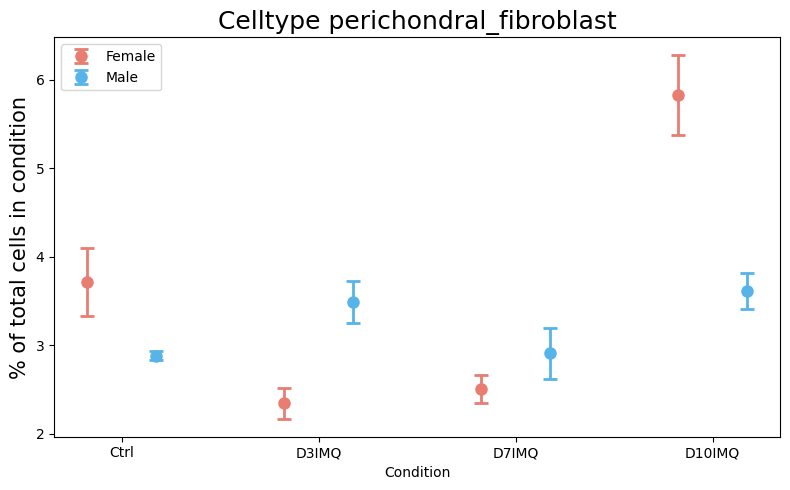

dermal_fibroblast


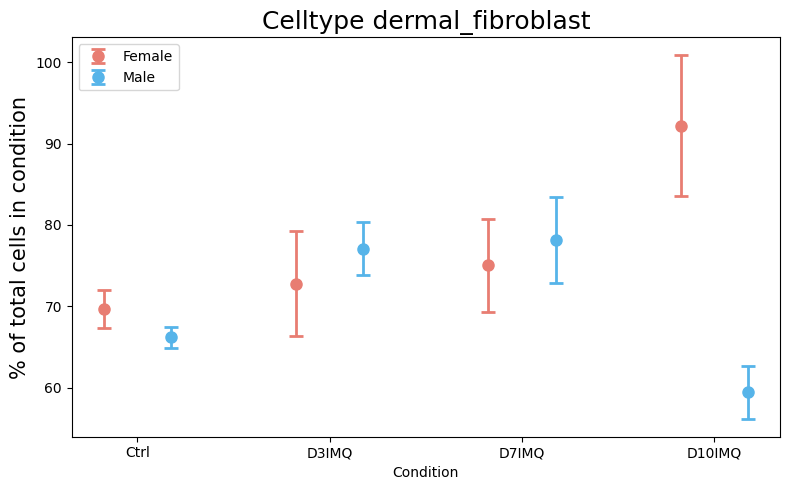

smc


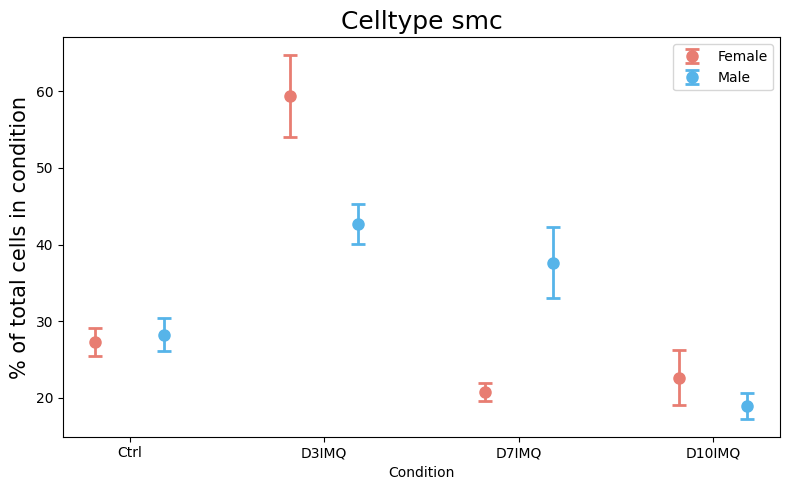

myeloid


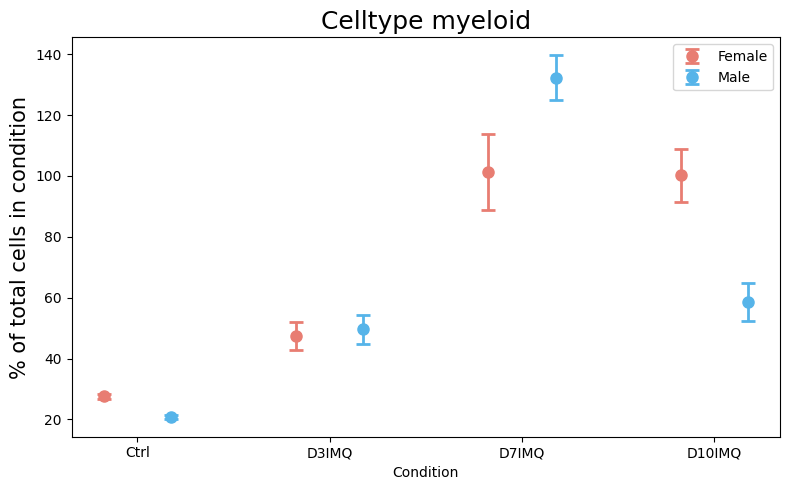

endothelial


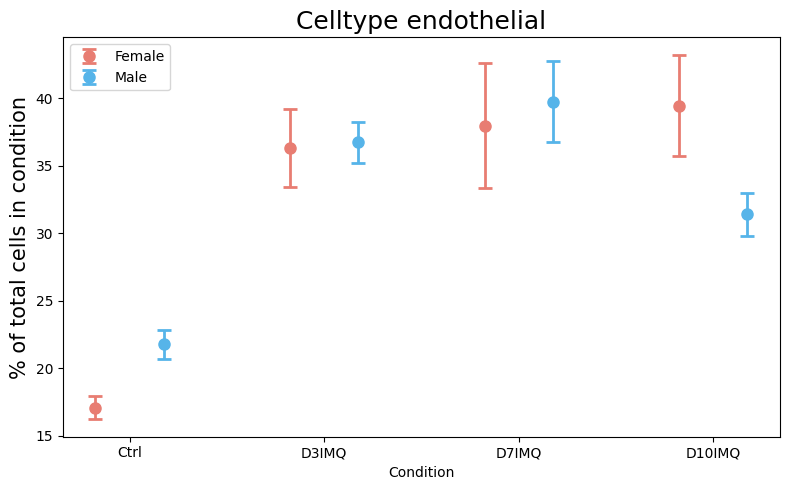

follicle_cell


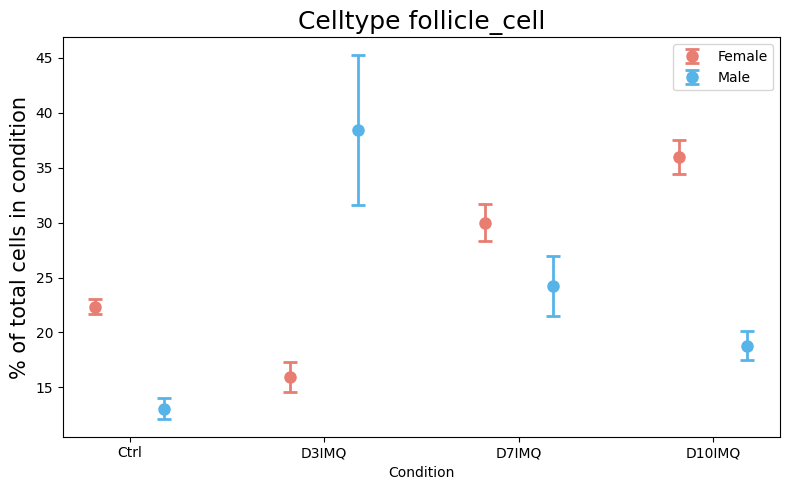

schwann_cell


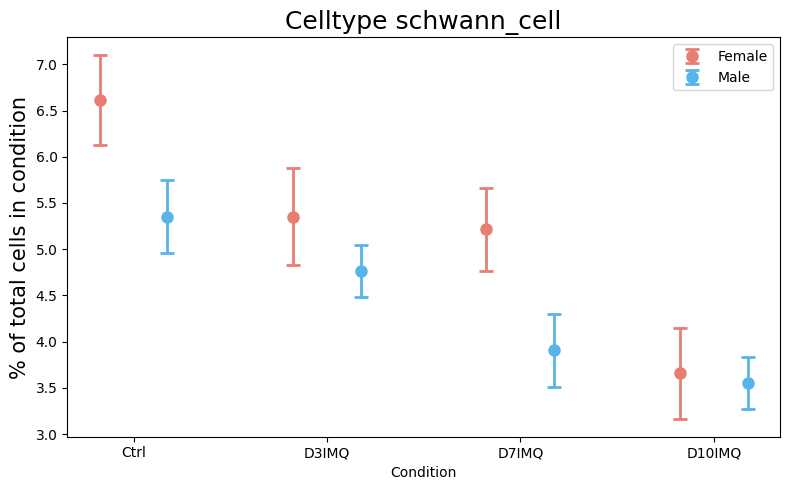

M2-like_macrophage


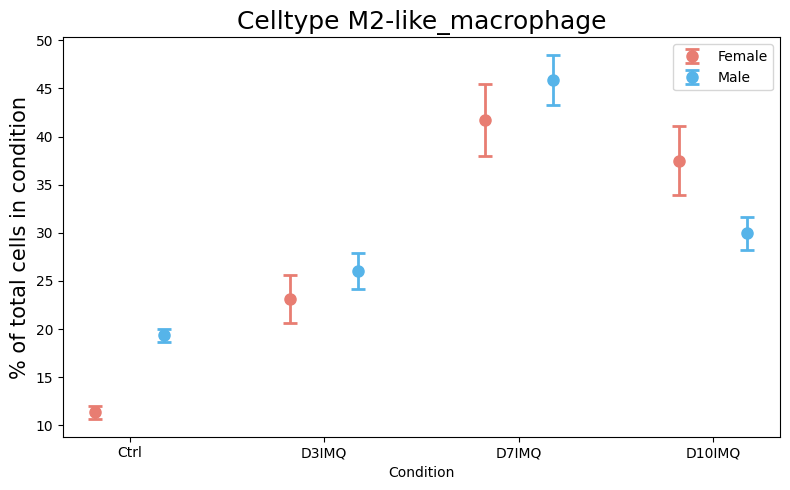

activated_basal_KC


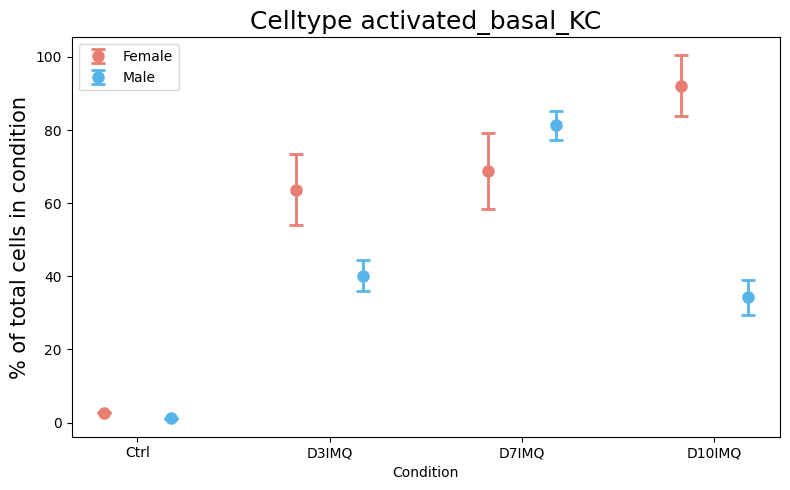

mast_cell


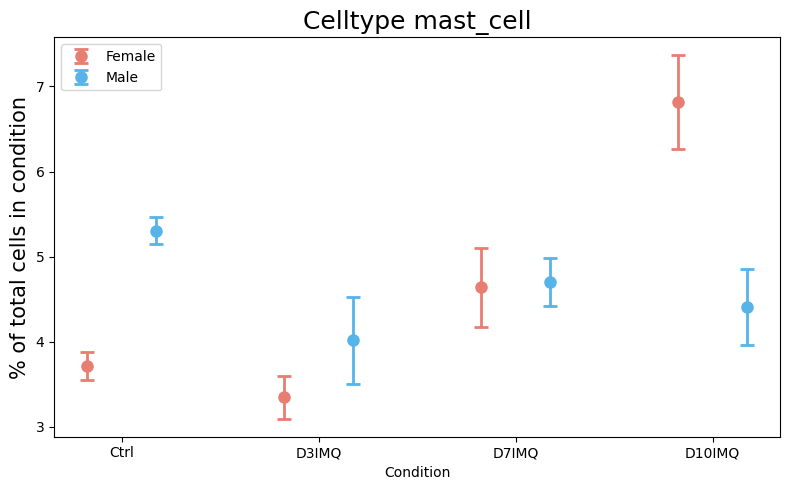

sebaceous_epithelial


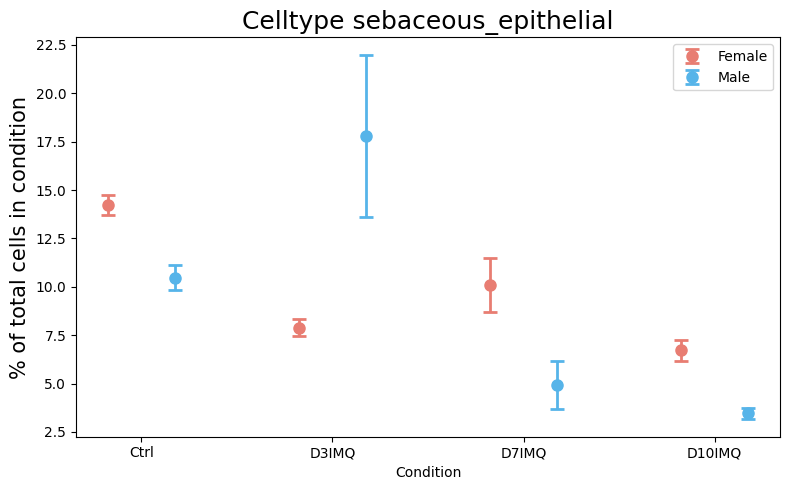

adipocyte


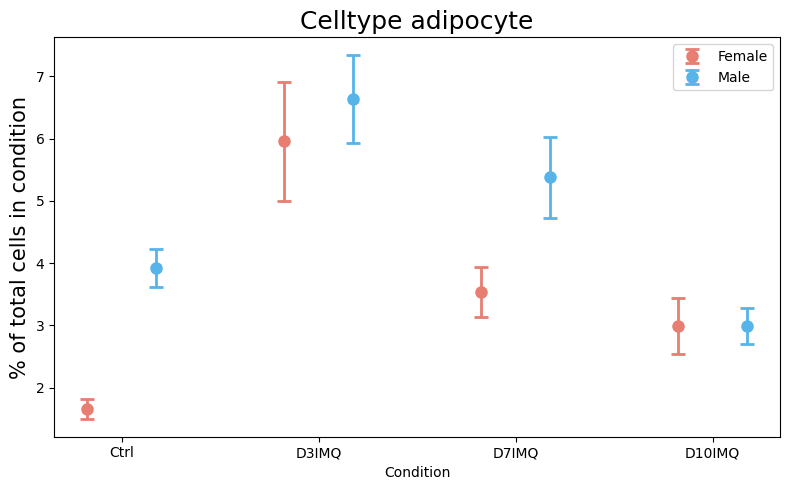

intermediate_basal_suprabasal_KC


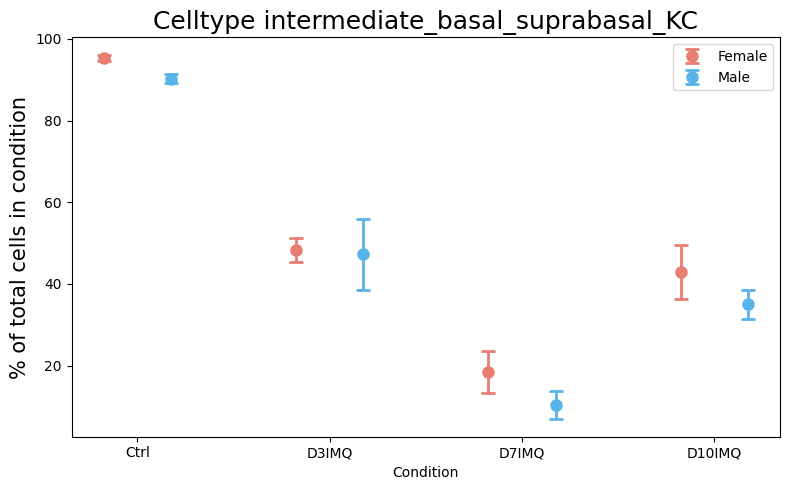

basal_KC


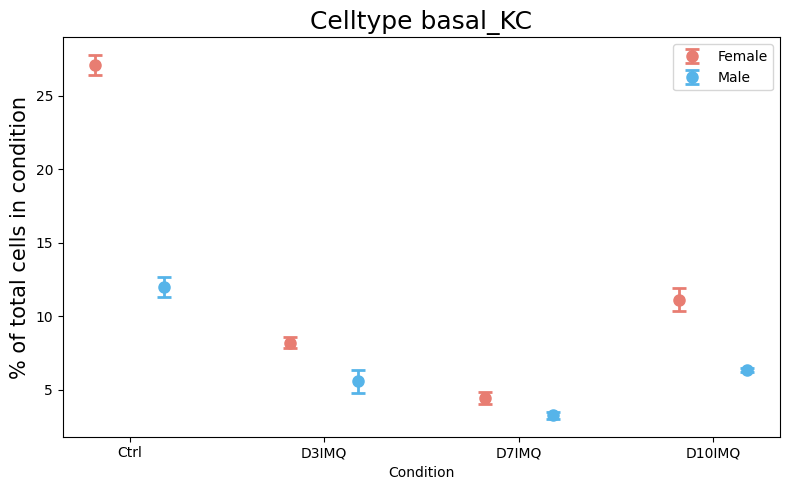

suprabasal_KC


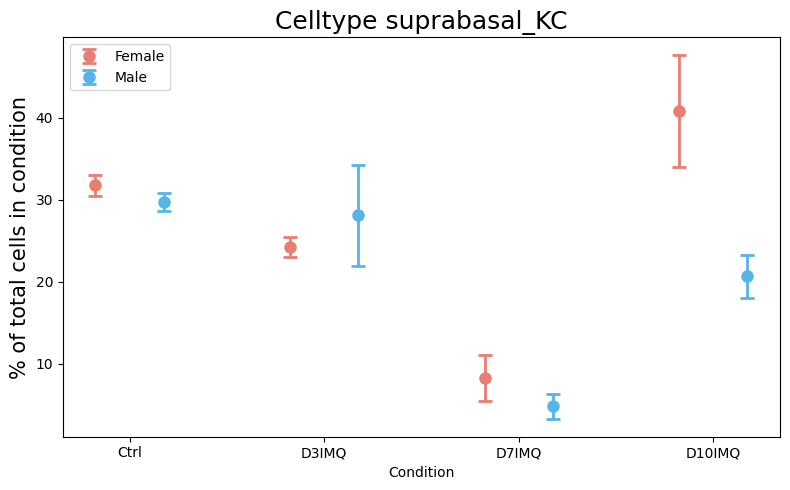

activated_suprabasal_KC


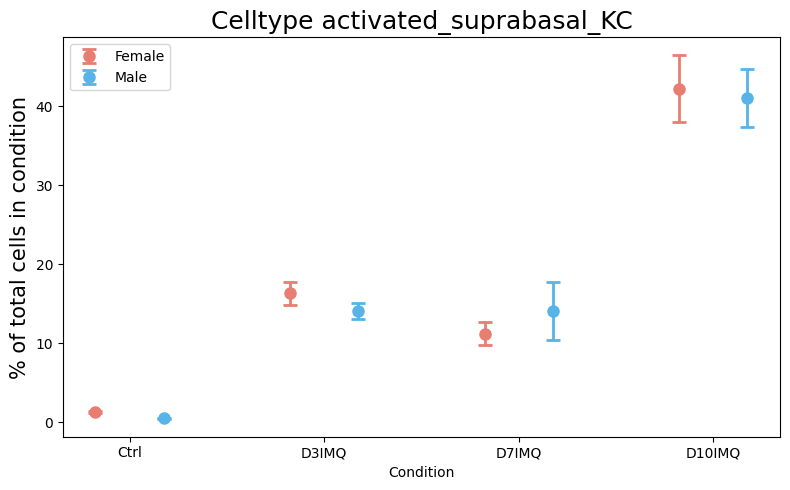

corneocyte


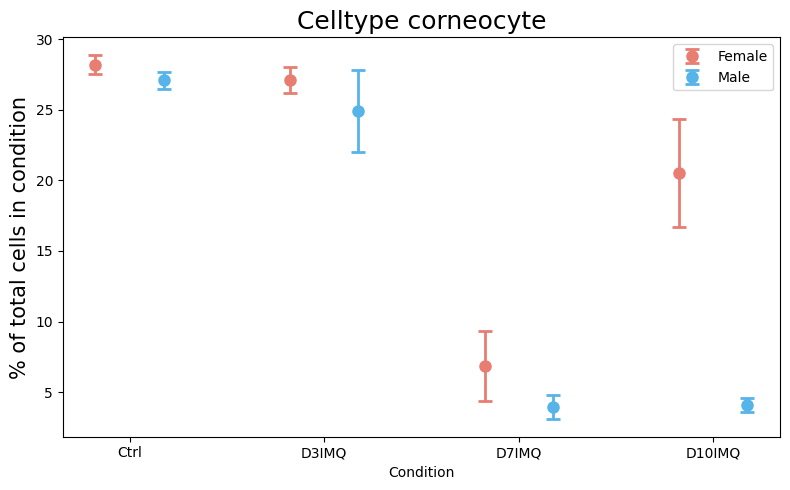

activated_corneocyte


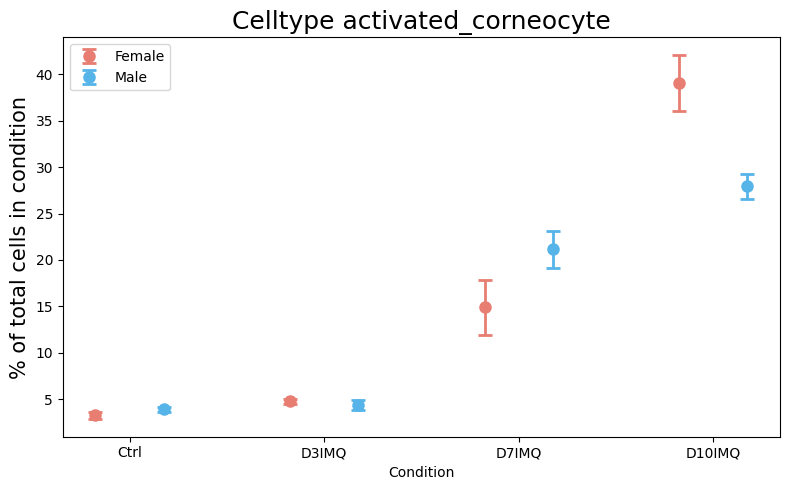

late_activated_suprabasal_KC


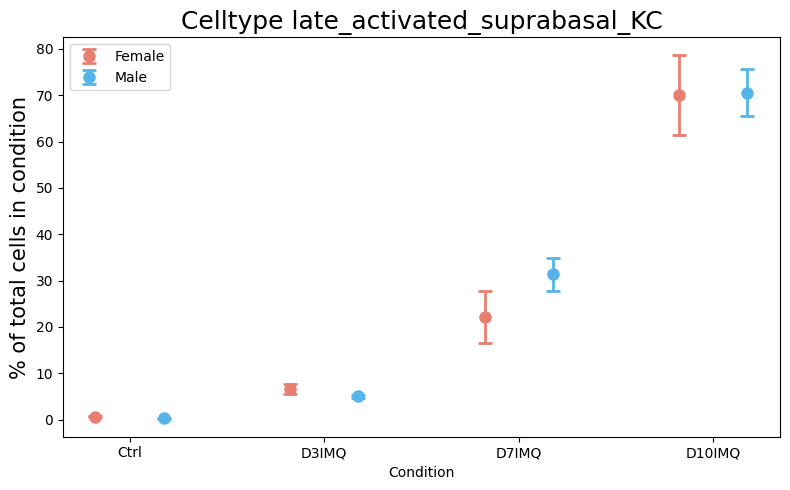

neutrophil


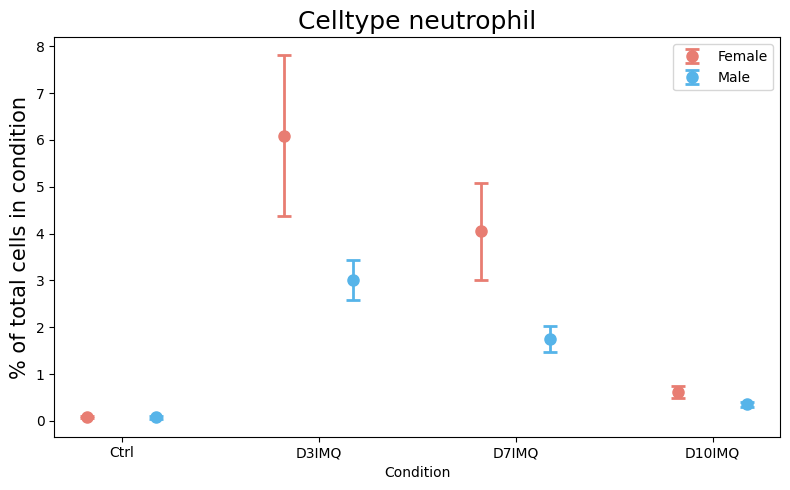

chondrocyte


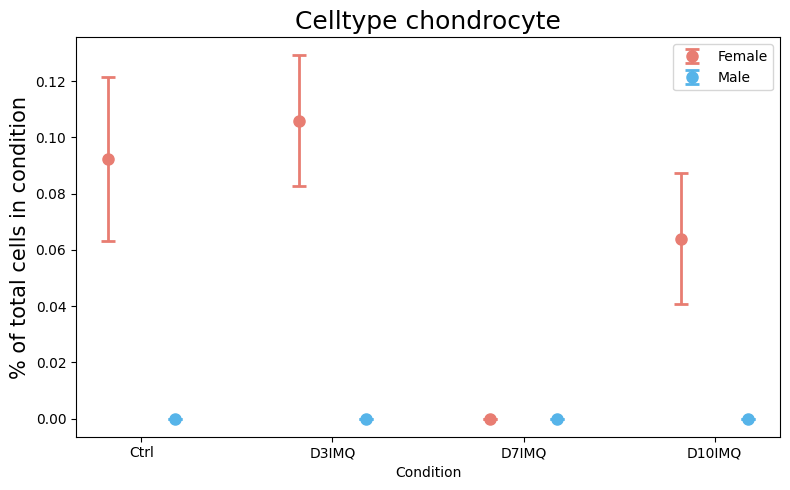

activated_intermediate_basal_suprabasal_KC


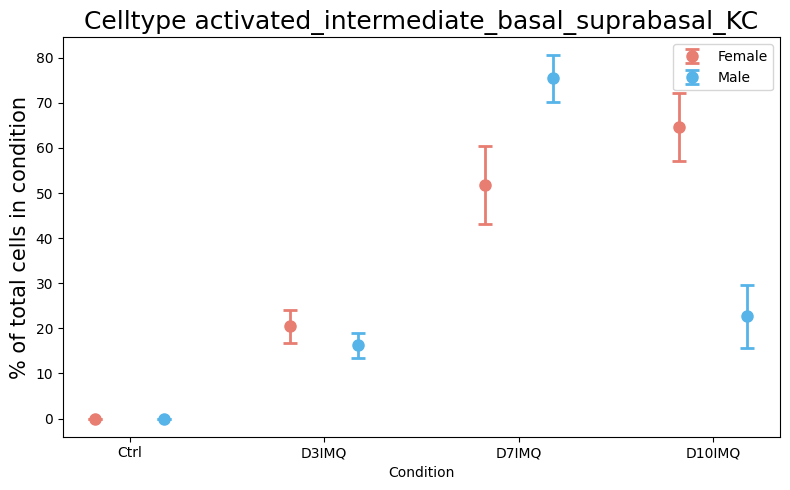

activated_spinous


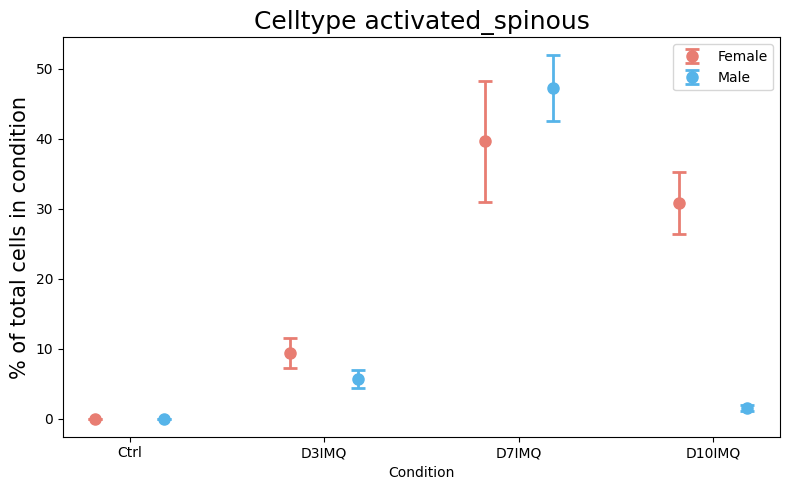

In [46]:
#normalised to cells in whatever is in 'normalisation_compartment'
#mean and error bar (std) version of above plot

import matplotlib.pyplot as plt
import pandas as pd
import math

condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

# Convert to string to avoid categorical dtype issues
bdata.obs['batch_key'] = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)

batch_totals = cdata.obs['batch_key'].astype(str).value_counts() #KEY NORMALISATION STEP THAT DIFFERS FROM ABOVE FUNCTION

for cluster in bdata.obs['celltype_assignments'].unique():
    print(cluster)
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster].copy()

    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    props['condition'] = props['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    props['sex'] = props['batch_key'].str.extract(r'_([FM])\d+$')

    all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
    all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
    all_batches['sex'] = all_batches['batch_key'].str.extract(r'_([FM])\d+$')

    # Convert all relevant columns to string before merge/fillna
    for df in [props, all_batches]:
        for col in ['batch_key', 'condition', 'sex']:
            df[col] = df[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)  # Only fillna on the numeric column

    fig, ax = plt.subplots(figsize=(8, 5))

    sex_colors = {'F': '#E87D72', 'M': '#56B4E9'}
    sex_labels = {'F': 'Female', 'M': 'Male'}
    width = 0.35
    x = range(len(condition_order))

    for sex, offset in {'F': -width/2, 'M': width/2}.items():
        sex_data = props[props['sex'] == sex]

        num_replicates = len(adata.obs.batch_key.unique())
        means = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].mean() for cond in condition_order]
        stds  = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].std()/math.sqrt(num_replicates)  for cond in condition_order]

        positions = [xi + offset for xi in x]

        ax.errorbar(
            positions, means, yerr=stds,
            fmt='o', color=sex_colors[sex],
            ecolor=sex_colors[sex], elinewidth=2,
            capsize=5, capthick=2,
            markersize=8, label=sex_labels[sex],
            zorder=3
        )

        # # Overlay individual points
        # for pos, cond in zip(positions, condition_order):
        #     vals = sex_data.loc[sex_data['condition'] == cond, 'proportion'].values
        #     ax.scatter(
        #         [pos] * len(vals), vals,
        #         color=sex_colors[sex], edgecolors='black',
        #         linewidths=0.5, zorder=5, s=30, alpha=0.6
        #     )

    ax.set_xticks(list(x))
    ax.set_xticklabels(condition_order)
    ax.set_title(f'Celltype {cluster}', fontsize=18)
    ax.set_xlabel('Condition')
    ax.set_ylabel('% of total cells in condition', fontsize=15)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=sex_colors[s], alpha=0.7, label=sex_labels[s]) for s in ['F', 'M']]
    ax.legend()

    plt.tight_layout()
    plt.show()

In [48]:
bdata.obs.celltype_assignments.unique()

array(['perichondral_fibroblast', 'dermal_fibroblast', 'smc', 'myeloid',
       'endothelial', 'follicle_cell', 'schwann_cell',
       'M2-like_macrophage', 'activated_basal_KC', 'mast_cell',
       'sebaceous_epithelial', 'adipocyte',
       'intermediate_basal_suprabasal_KC', 'basal_KC', 'suprabasal_KC',
       'activated_suprabasal_KC', 'corneocyte', 'activated_corneocyte',
       'late_activated_suprabasal_KC', 'neutrophil', 'chondrocyte',
       'activated_intermediate_basal_suprabasal_KC', 'activated_spinous'],
      dtype=object)

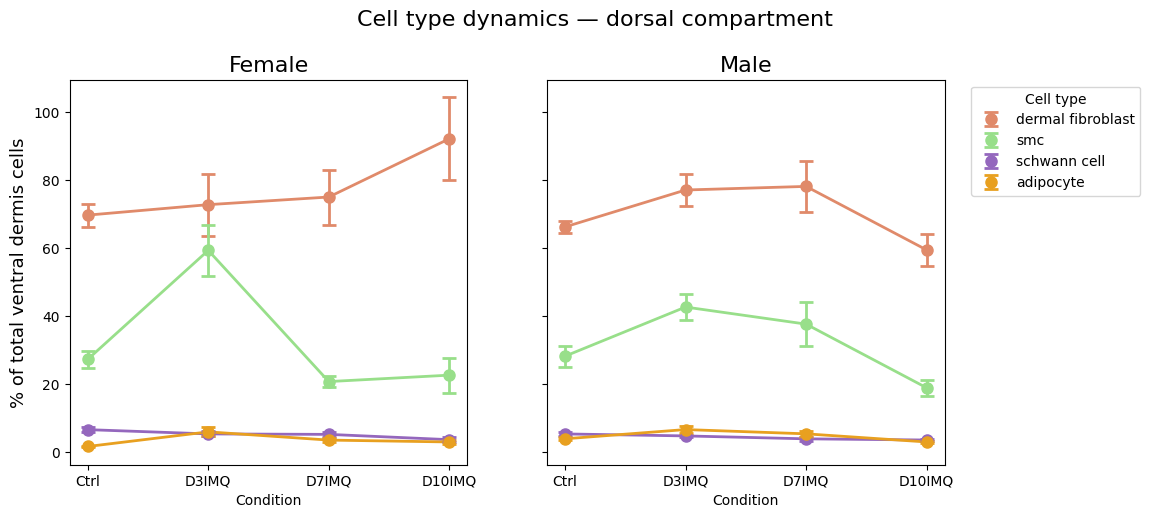

In [62]:
#visualising celltype dynamics, again, using the dorsal compartment and normalising to whatever is in normalisation compartment

import matplotlib.pyplot as plt
import pandas as pd
import math
import numpy as np

#clusters_to_plot = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']
#clusters_to_plot = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']
#clusters_to_plot = ['myeloid', 'neutrophil', 'M2-like_macrophage']
clusters_to_plot = ['dermal_fibroblast', 'smc', 'schwann_cell', 'adipocyte']

condition_order  = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']


# Build colour map from AnnData
sorted_clusters = sorted(adata.obs['celltype_assignments'].unique())
color_map = dict(zip(sorted_clusters, adata.uns['celltype_assignments_colors']))

# Precompute normalisation denominators
bdata.obs['batch_key']            = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)
batch_totals = cdata.obs['batch_key'].astype(str).value_counts()

all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
for col in ['batch_key', 'condition', 'sex']:
    all_batches[col] = all_batches[col].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sex_labels = {'F': 'Female', 'M': 'Male'}
x = np.arange(len(condition_order))

for cluster in clusters_to_plot:
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster]
    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    for col in ['batch_key']:
        props[col] = props[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)

    color = color_map[cluster]

    for ax, (sex, sex_label) in zip(axes, sex_labels.items()):
        sex_data = props[props['sex'] == sex]

        num_replicates = len(sex_data['batch_key'].unique())

        means = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].mean()
                 for cond in condition_order]
        sems  = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].std()
                 / math.sqrt(num_replicates)
                 for cond in condition_order]

        ax.plot(x, means, color=color, linewidth=2, zorder=3)
        ax.errorbar(
            x, means, yerr=sems,
            fmt='o', color=color,
            ecolor=color, elinewidth=2,
            capsize=5, capthick=2,
            markersize=8, label=cluster.replace('_', ' '),
            zorder=4
        )

for ax, (sex, sex_label) in zip(axes, sex_labels.items()):
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order)
    ax.set_title(sex_label, fontsize=16)
    ax.set_xlabel('Condition')

comp_label = normalisation_compartment.replace("_", " ")
axes[0].set_ylabel(f'% of total {comp_label} cells', fontsize=13)

axes[1].legend(title='Cell type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.subplots_adjust(right=0.75)


plt.suptitle('Cell type dynamics — dorsal compartment', fontsize=16, y=1.02)
plt.show()

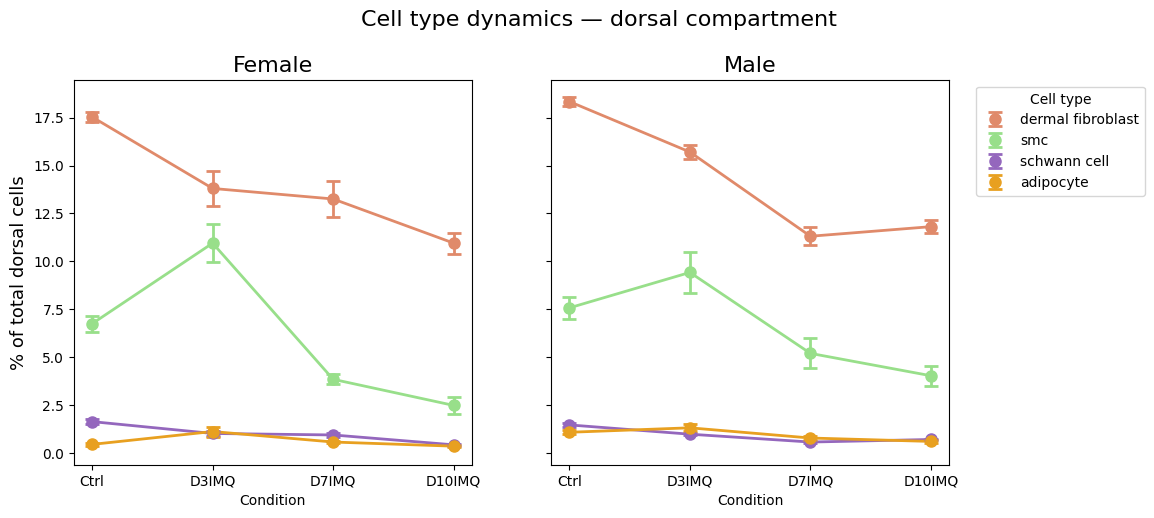

In [63]:
#visualising celltype dynamics, normalised to total cells in dorsal compartment

import matplotlib.pyplot as plt
import pandas as pd
import math
import numpy as np

#clusters_to_plot = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']
#clusters_to_plot = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']
#clusters_to_plot = ['myeloid', 'neutrophil', 'M2-like_macrophage']
clusters_to_plot = ['dermal_fibroblast', 'smc', 'schwann_cell', 'adipocyte']


condition_order  = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']


# Build colour map from AnnData
sorted_clusters = sorted(adata.obs['celltype_assignments'].unique())
color_map = dict(zip(sorted_clusters, adata.uns['celltype_assignments_colors']))

# Precompute normalisation denominators
bdata.obs['batch_key']            = bdata.obs['batch_key'].astype(str)
bdata.obs['celltype_assignments'] = bdata.obs['celltype_assignments'].astype(str)
batch_totals = bdata.obs['batch_key'].value_counts()

all_batches = bdata.obs[['batch_key']].drop_duplicates().copy()
all_batches['condition'] = all_batches['batch_key'].str.extract(r'^(.+)_[FM]\d+$')
all_batches['sex']       = all_batches['batch_key'].str.extract(r'_([FM])\d+$')
for col in ['batch_key', 'condition', 'sex']:
    all_batches[col] = all_batches[col].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sex_labels = {'F': 'Female', 'M': 'Male'}
x = np.arange(len(condition_order))

for cluster in clusters_to_plot:
    cluster_data = bdata[bdata.obs['celltype_assignments'] == cluster]
    batch_counts = cluster_data.obs['batch_key'].value_counts()

    props = (batch_counts / batch_totals * 100).rename('proportion').reset_index()
    props.columns = ['batch_key', 'proportion']
    for col in ['batch_key']:
        props[col] = props[col].astype(str)

    props = all_batches.merge(props[['batch_key', 'proportion']], on='batch_key', how='left')
    props['proportion'] = props['proportion'].fillna(0)

    color = color_map[cluster]

    for ax, (sex, sex_label) in zip(axes, sex_labels.items()):
        sex_data = props[props['sex'] == sex]

        num_replicates = len(sex_data['batch_key'].unique())

        means = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].mean()
                 for cond in condition_order]
        sems  = [sex_data.loc[sex_data['condition'] == cond, 'proportion'].std()
                 / math.sqrt(num_replicates)
                 for cond in condition_order]

        ax.plot(x, means, color=color, linewidth=2, zorder=3)
        ax.errorbar(
            x, means, yerr=sems,
            fmt='o', color=color,
            ecolor=color, elinewidth=2,
            capsize=5, capthick=2,
            markersize=8, label=cluster.replace('_', ' '),
            zorder=4
        )

for ax, (sex, sex_label) in zip(axes, sex_labels.items()):
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order)
    ax.set_title(sex_label, fontsize=16)
    ax.set_xlabel('Condition')

comp_label = 'dorsal'
axes[0].set_ylabel(f'% of total {comp_label} cells', fontsize=13)

axes[1].legend(title='Cell type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.subplots_adjust(right=0.75)


plt.suptitle('Cell type dynamics — dorsal compartment', fontsize=16, y=1.02)
plt.show()

0


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


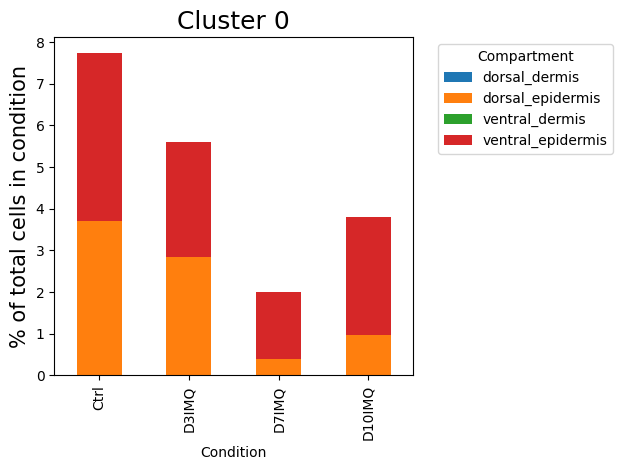

compartment  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                      
Ctrl               0.00000          3.696711        0.000000   
D3IMQ              0.00000          2.838487        0.002244   
D7IMQ              0.00000          0.386034        0.000000   
D10IMQ             0.00172          0.968486        0.000000   

compartment  ventral_epidermis  
condition                       
Ctrl                  4.029613  
D3IMQ                 2.753220  
D7IMQ                 1.616786  
D10IMQ                2.843529  
1


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


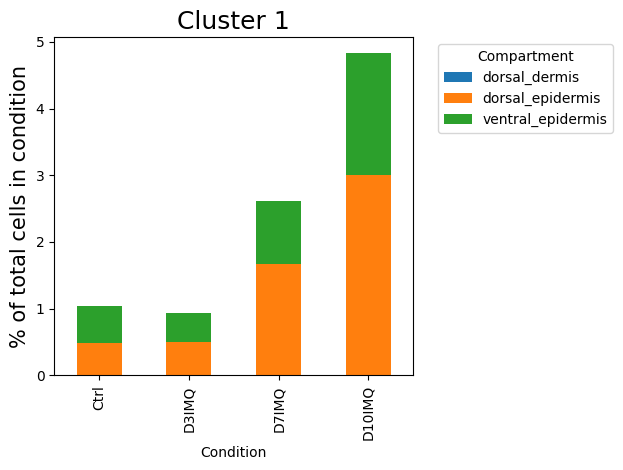

compartment  dorsal_dermis  dorsal_epidermis  ventral_epidermis
condition                                                      
Ctrl               0.00000          0.491901           0.556494
D3IMQ              0.00000          0.502625           0.433066
D7IMQ              0.00000          1.669492           0.944431
D10IMQ             0.00172          2.994908           1.828597
2


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


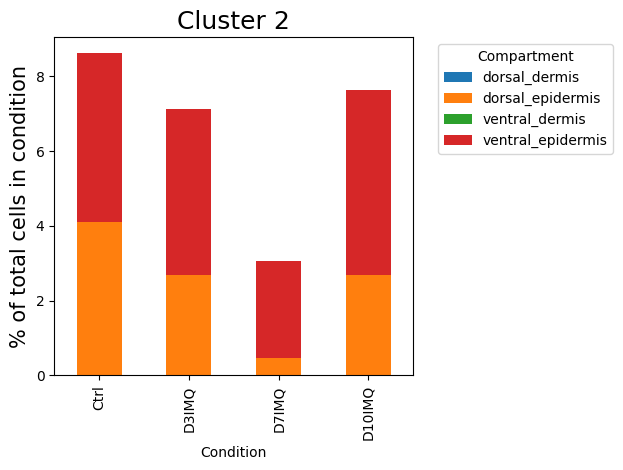

compartment  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                      
Ctrl               0.00000          4.114081        0.000000   
D3IMQ              0.00000          2.694880        0.000000   
D7IMQ              0.00000          0.461532        0.001424   
D10IMQ             0.00172          2.683548        0.000000   

compartment  ventral_epidermis  
condition                       
Ctrl                  4.501640  
D3IMQ                 4.442849  
D7IMQ                 2.598254  
D10IMQ                4.954242  
3


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


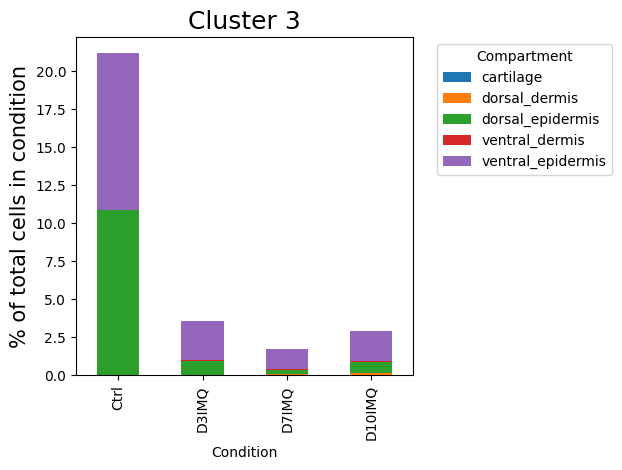

compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          0.009937       0.024843         10.831760        0.014906   
D3IMQ         0.008975       0.031414          0.911008        0.056097   
D7IMQ         0.005698       0.095440          0.267802        0.034188   
D10IMQ        0.018922       0.115255          0.744857        0.086011   

compartment  ventral_epidermis  
condition                       
Ctrl                 10.275266  
D3IMQ                 2.573711  
D7IMQ                 1.336163  
D10IMQ                1.949013  
4


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


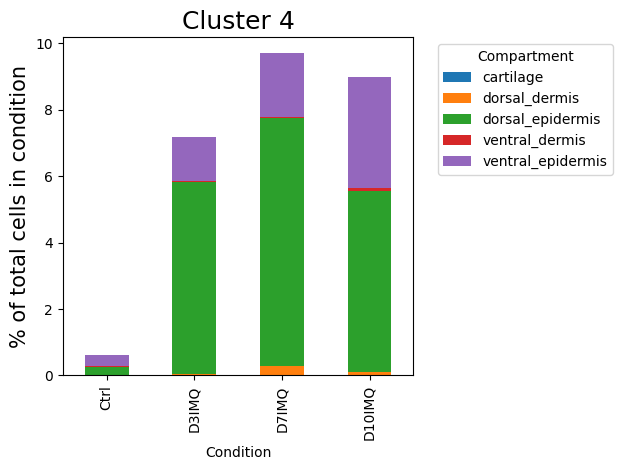

compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          0.004969       0.014906          0.238497        0.034781   
D3IMQ         0.004488       0.038146          5.775703        0.031414   
D7IMQ         0.002849       0.290594          7.450036        0.044159   
D10IMQ        0.005161       0.094612          5.458267        0.082571   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.332903  
D3IMQ                 1.326123  
D7IMQ                 1.911654  
D10IMQ                3.356155  
5


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


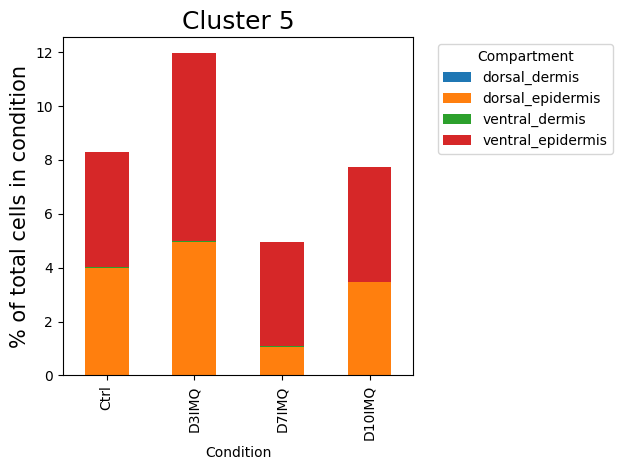

compartment  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                      
Ctrl              0.004969          3.984895        0.024843   
D3IMQ             0.008975          4.934255        0.056097   
D7IMQ             0.019943          1.038447        0.021367   
D10IMQ            0.017202          3.455928        0.010321   

compartment  ventral_epidermis  
condition                       
Ctrl                  4.297923  
D3IMQ                 6.955975  
D7IMQ                 3.880287  
D10IMQ                4.254111  
6


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


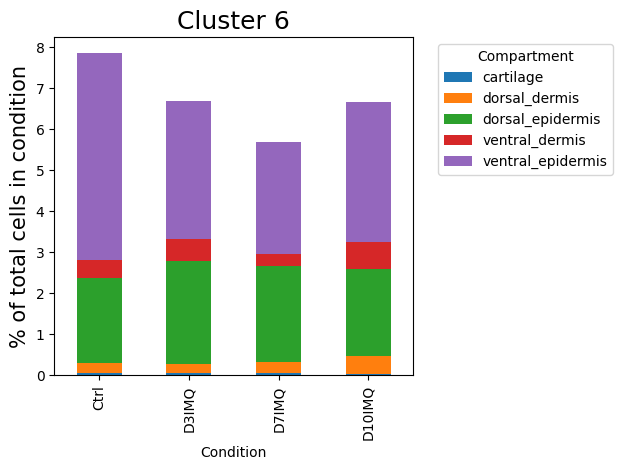

compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          0.059624       0.238497          2.086853        0.432277   
D3IMQ         0.051609       0.226630          2.508639        0.543015   
D7IMQ         0.052706       0.282047          2.334725        0.297717   
D10IMQ        0.036125       0.448978          2.110714        0.651964   

compartment  ventral_epidermis  
condition                       
Ctrl                  5.028322  
D3IMQ                 3.363551  
D7IMQ                 2.722183  
D10IMQ                3.406041  
7


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


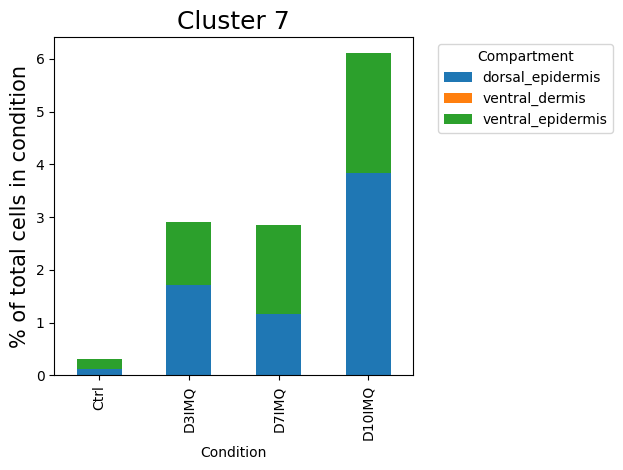

compartment  dorsal_epidermis  ventral_dermis  ventral_epidermis
condition                                                       
Ctrl                 0.119249        0.000000           0.188810
D3IMQ                1.718799        0.000000           1.195979
D7IMQ                1.163801        0.001424           1.693708
D10IMQ               3.839538        0.000000           2.262093
8


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


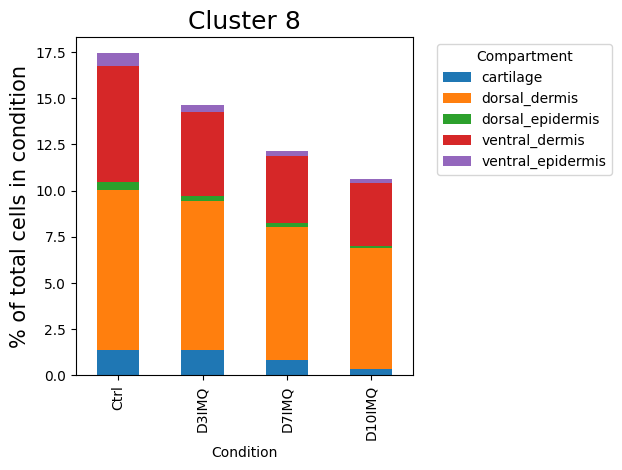

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          1.386267       8.625658          0.452151        6.280433   
D3IMQ         1.377732       8.084639          0.273751        4.528116   
D7IMQ         0.819077       7.187932          0.233615        3.659492   
D10IMQ        0.338884       6.547169          0.115255        3.392280   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.680712  
D3IMQ                 0.367994  
D7IMQ                 0.253558  
D10IMQ                0.251153  
9


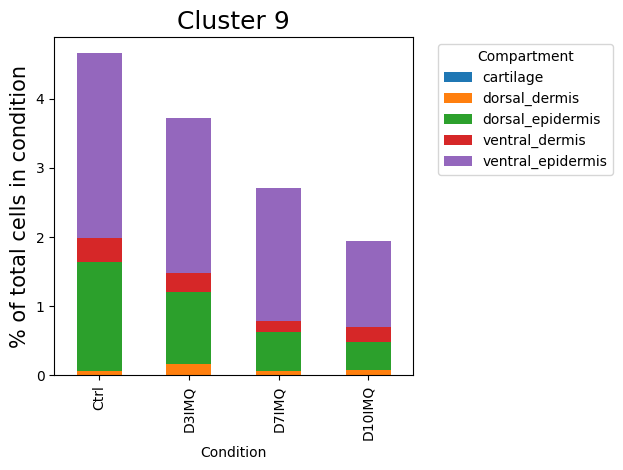

compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          0.009937       0.054656          1.570108        0.347809   
D3IMQ         0.004488       0.157070          1.052372        0.273751   
D7IMQ         0.005698       0.052706          0.572641        0.149571   
D10IMQ        0.000000       0.077410          0.411133        0.206427   

compartment  ventral_epidermis  
condition                       
Ctrl                  2.673159  
D3IMQ                 2.230400  
D7IMQ                 1.931596  
D10IMQ                1.248882  
10


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


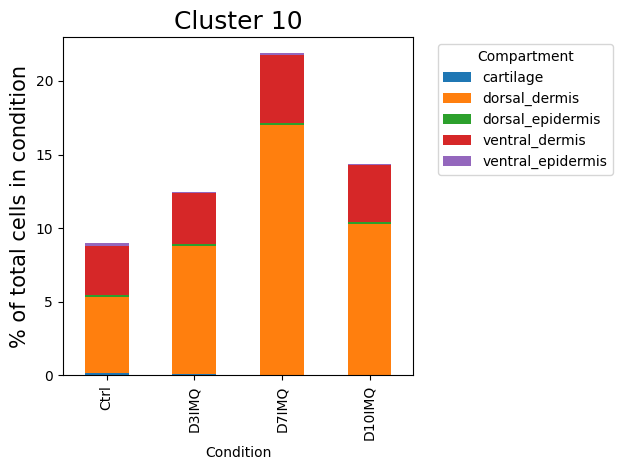

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          0.178873       5.127696          0.158998        3.353871   
D3IMQ         0.089755       8.699457          0.112193        3.504914   
D7IMQ         0.058404      16.968419          0.150995        4.595376   
D10IMQ        0.061928      10.257689          0.084291        3.892865   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.144092  
D3IMQ                 0.065072  
D7IMQ                 0.098289  
D10IMQ                0.080850  
11


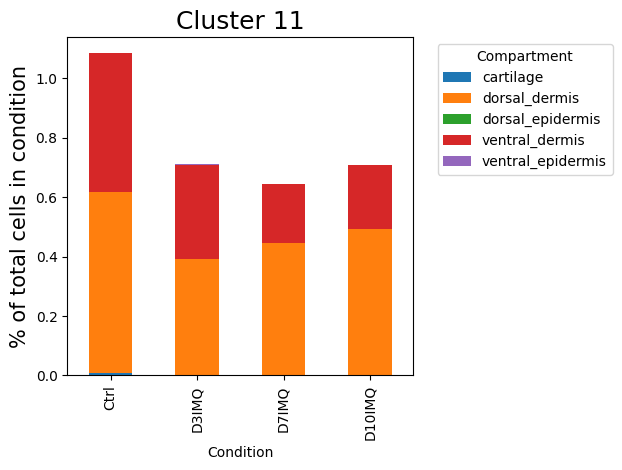

compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          0.009937       0.606181          0.000000        0.467058   
D3IMQ         0.002244       0.388188          0.002244        0.316385   
D7IMQ         0.001424       0.444438          0.000000        0.198003   
D10IMQ        0.000000       0.493704          0.000000        0.215028   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.000000  
D3IMQ                 0.002244  
D7IMQ                 0.001424  
D10IMQ                0.000000  
12


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


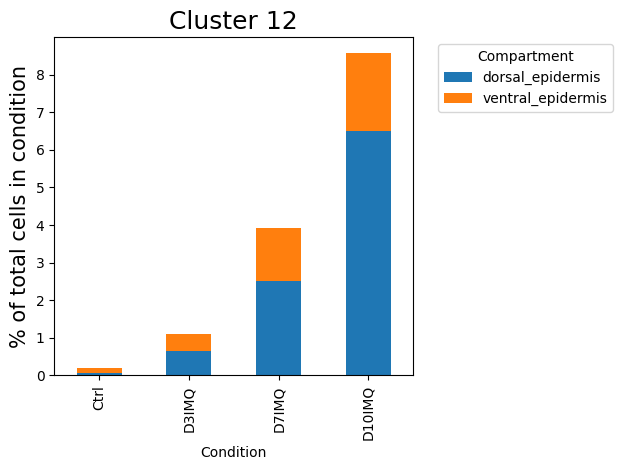

compartment  dorsal_epidermis  ventral_epidermis
condition                                       
Ctrl                 0.059624           0.144092
D3IMQ                0.657452           0.435309
D7IMQ                2.525605           1.407387
D10IMQ               6.504163           2.060827
13


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


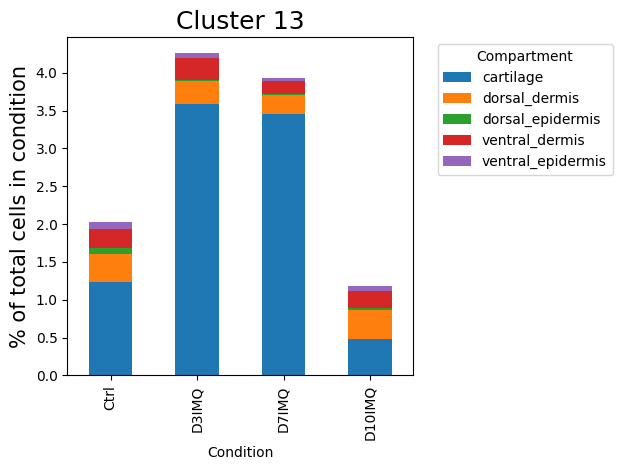

compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          1.232237       0.372652          0.074530        0.253404   
D3IMQ         3.581205       0.307409          0.017951        0.291702   
D7IMQ         3.455791       0.245011          0.011396        0.183758   
D10IMQ        0.478222       0.392211          0.027524        0.215028   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.094405  
D3IMQ                 0.056097  
D7IMQ                 0.035612  
D10IMQ                0.072249  
14


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


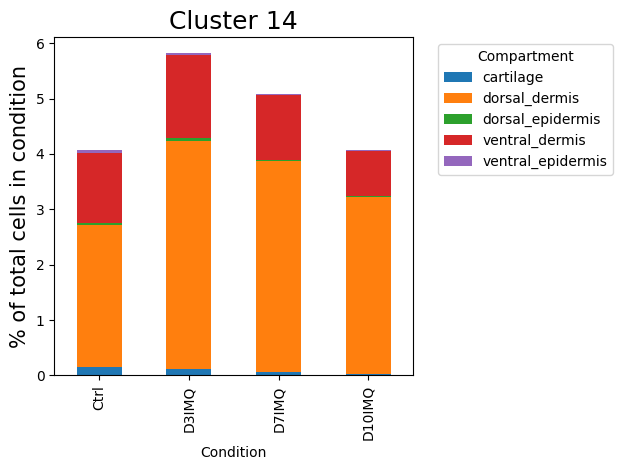

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          0.144092       2.578754          0.029812        1.267018   
D3IMQ         0.116681       4.115245          0.056097        1.496657   
D7IMQ         0.058404       3.809063          0.027065        1.166650   
D10IMQ        0.018922       3.209936          0.006881        0.822267   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.054656  
D3IMQ                 0.029170  
D7IMQ                 0.025641  
D10IMQ                0.013762  
15


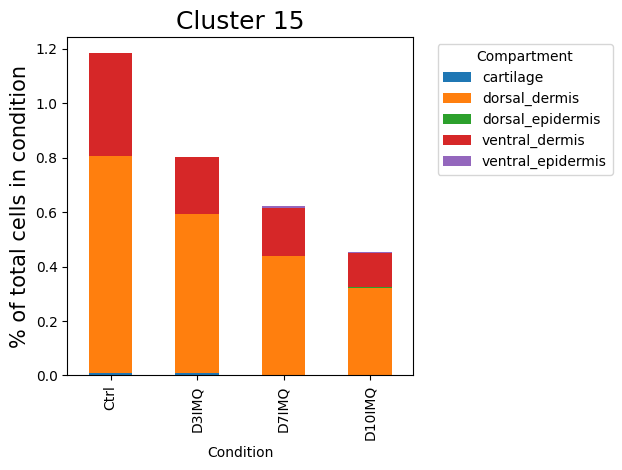

compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          0.009937       0.794992          0.000000        0.377621   
D3IMQ         0.008975       0.583404          0.002244        0.206435   
D7IMQ         0.001424       0.437316          0.000000        0.178060   
D10IMQ        0.000000       0.319961          0.003440        0.127296   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.000000  
D3IMQ                 0.002244  
D7IMQ                 0.004273  
D10IMQ                0.001720  
16


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


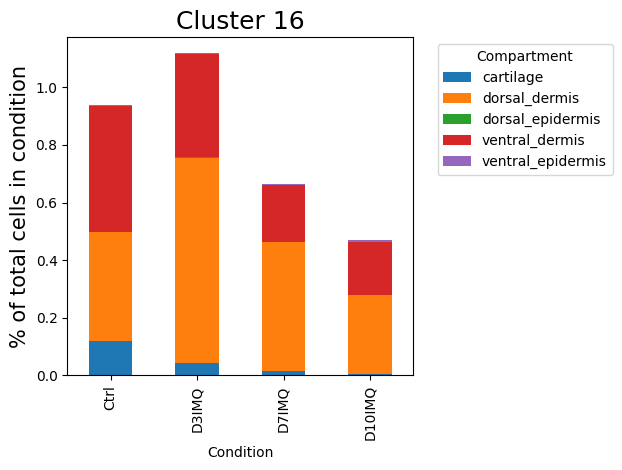

compartment  cartilage  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                                 
Ctrl          0.119249       0.377621          0.000000        0.437245   
D3IMQ         0.044877       0.709061          0.004488        0.356774   
D7IMQ         0.014245       0.447287          0.000000        0.199427   
D10IMQ        0.005161       0.273515          0.000000        0.185784   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.004969  
D3IMQ                 0.002244  
D7IMQ                 0.002849  
D10IMQ                0.005161  
17


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


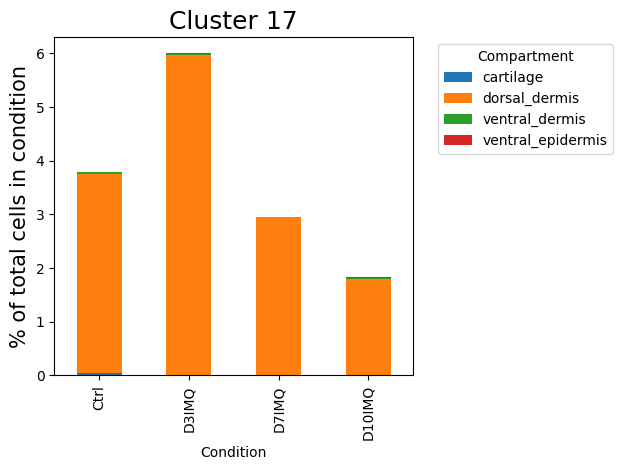

compartment  cartilage  dorsal_dermis  ventral_dermis  ventral_epidermis
condition                                                               
Ctrl          0.054656       3.701679        0.034781           0.004969
D3IMQ         0.002244       5.970920        0.022439           0.002244
D7IMQ         0.008547       2.938705        0.008547           0.000000
D10IMQ        0.003440       1.794193        0.022363           0.006881
18


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


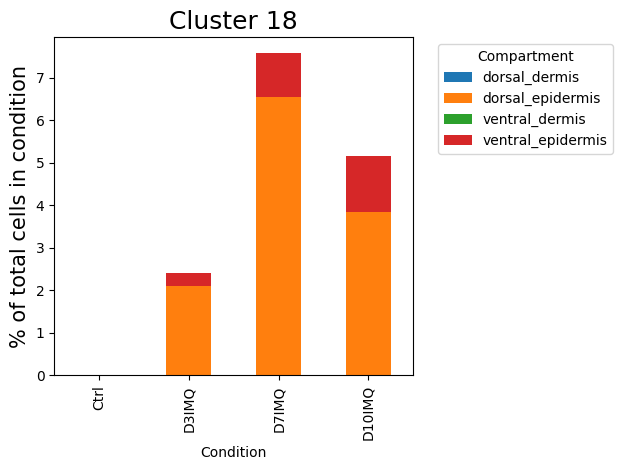

compartment  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                      
Ctrl              0.000000          0.000000         0.00000   
D3IMQ             0.000000          2.104744         0.00000   
D7IMQ             0.004273          6.541217         0.00000   
D10IMQ            0.003440          3.830936         0.00172   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.009937  
D3IMQ                 0.298434  
D7IMQ                 1.031324  
D10IMQ                1.331453  
19


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_41608\2077022035.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)


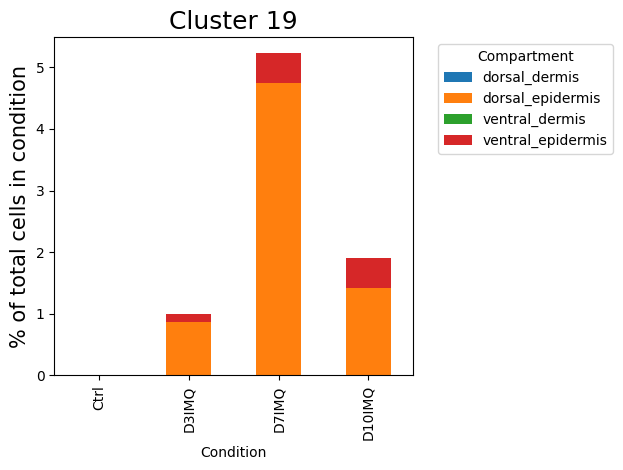

compartment  dorsal_dermis  dorsal_epidermis  ventral_dermis  \
condition                                                      
Ctrl              0.000000          0.000000         0.00000   
D3IMQ             0.000000          0.859400         0.00000   
D7IMQ             0.001424          4.750645         0.00000   
D10IMQ            0.001720          1.415743         0.00172   

compartment  ventral_epidermis  
condition                       
Ctrl                  0.000000  
D3IMQ                 0.136876  
D7IMQ                 0.471503  
D10IMQ                0.485103  


In [ ]:
# by compartment version of the above plot

import matplotlib.pyplot as plt

condition_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']
condition_totals = bdata.obs['condition'].value_counts()

for cluster in bdata.obs['leiden_0.75'].unique():
    print(cluster)
    cluster_data = bdata[bdata.obs['leiden_0.75'] == cluster].copy()

    # Raw counts grouped by condition and compartment
    compartment_counts = cluster_data.obs.groupby(['condition', 'compartment']).size().unstack(fill_value=0)
    
    # Reindex conditions, then divide each row by condition total
    compartment_counts = compartment_counts.reindex(condition_order, fill_value=0)
    compartment_props = compartment_counts.div(condition_totals, axis=0) * 100

    compartment_props = compartment_props.reindex(condition_order)
    # Stacked bar plot
    compartment_props.plot(kind='bar', stacked=True, ax=plt.subplots()[1])
    
    plt.title(f'Cluster {cluster}', fontsize=18)
    plt.xlabel('Condition')
    plt.ylabel('% of total cells in condition', fontsize=15)
    plt.legend(title='Compartment', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

    print(compartment_props)